<h1 style="font-size:25px; font-weight:700; margin-bottom:10px;">
Credit Risk Modeling
</h1>

<div style="font-size:24px; font-family:'Times New Roman', Times, serif; margin-top:0px;">
<i>An empirical evaluation of logistic regression, random forest, SVM, and XGBoost models</i>
</div>


## Abstract

**Study Design & Methodology**
- Developed predictive models for loan default using LendingClub data
- Compared simple vs complex modeling approaches
- Models evaluated Baseline Logistic Regression, XGBoost, Random Forest, Support Vector Machine (SVM)
- Goal to determine if added complexity materially improves discrimination and/or calibration
- Applied time-based training/test split to reflect real-world deployment
- Trained on historical loans, tested on newer loans
- Evaluation metrics AUC (model discrimination), KS Statistic (class separation strength), Decile Default Rates (risk ranking effectiveness), Brier Score/Calibration Curves (probability accuracy)
- AUC provides a threshold-independent measure of model discrimination and evaluates ranking performance without distortion from class imbalance
- Differences in model performance evaluated using the DeLong test for statistical significance of AUC
- Tested whether calibration differences were a genuine model property or a fixable modeling-choice artifact, via post-hoc recalibration (Platt scaling)

**Key Results**
- Increasing model complexity did not improve discrimination: Random Forest, XGBoost, and SVM all track the baseline closely in AUC/KS, with none reaching statistical significance over the baseline (DeLong test, p > 0.45)
- The baseline initially appears worse calibrated than XGBoost/Random Forest (Brier 0.2309 vs 0.1664/0.1672), but this gap is entirely an artifact of `class_weight='balanced'`, not a limitation of the linear model
- A simple post-hoc recalibration (Platt scaling) closes the gap completely (Brier 0.2309 to 0.1667) with no change to AUC, putting the baseline on par with XGBoost and Random Forest on both criteria
- LendingClub grade system outperformed all models on discrimination, and is the only statistically significant comparison
- The grade advantage is more plausibly explained by access to third-party/non-traditional credit data used in their proprietary underwriting than by superior modeling technique

**Interpretation & Implications**
- Complexity delivered no genuine advantage in this study, on discrimination or on calibration, once the baseline is properly recalibrated
- Apparent calibration differences between models can reflect a fixable modeling choice rather than an inherent property of model complexity; recalibration should be tested before concluding otherwise
- Feature quality drives discrimination more than model choice does; a cheap post-hoc step, not added complexity, drives calibration
- A recalibrated logistic baseline is competitive on both ranking-based and probability-dependent decisions, removing the need to trade interpretability for calibration
- LendingClub's own grade outperforming every model built here points to feature access, not model sophistication, as the more promising lever for closing the remaining gap

## 1.0 Introduction

**Why does this study matter?**
- Credit risk models support approval, pricing, and portfolio risk management decisions
- Models must balance predictive performance with interpretability, especially in regulated settings
- Study uses LendingClub data to predict loan default with data available at time of origination

**What were the modeling approaches used?**
- Regularized logistic regression used as the baseline for interpretability and stability, serving as the reference model for all comparisons
- Alternative models evaluated using a time-based training/test split
- Performance evaluated using area under the curve, ks statistic, gini coefficent 

**Where did the data come from?**
- Uses LendingClub accepted loans dataset (2007–2018) from Kaggle
- Includes borrower, credit, loan, and outcome information
- Rejected applications dataset excluded due to lack of observable performance outcomes

**Is the data reliable?**
- Performed basic data checks to confirm structure, consistency, and absence of duplicate loan identifiers


> Public access to the dataset and accompanying data dictionary is available via Kaggle:  
> ▪ Dataset: https://www.kaggle.com/datasets/wordsforthewise/lending-club  
> ▪ Data Dictionary: https://www.kaggle.com/datasets/jonchan2003/lending-club-data-dictionary


### Initialize Environment


In [1]:
# Standard Libraries
import math
import os
import sys
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
from IPython.display import display, HTML

# Scikit-Learn: Preprocessing & Pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import clone

# Scikit-Learn: Models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.kernel_approximation import Nystroem

# Scikit-Learn: Model Selection & Metrics
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, brier_score_loss
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Boosting Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Utilities
from itertools import combinations
from scipy import stats
import joblib

# Silences Multiprocessing Warning
os.environ.pop('MallocStackLogging', None)


In [2]:
# Global Settings
sns.set_theme(style = 'whitegrid')


In [3]:
# Function: Fit Logit Model
def fit_logit_model(X_tr, y_tr, numeric_cols, cat_cols, C = 1.0):
    
    pre = ColumnTransformer([
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop = 'first', handle_unknown = 'ignore'), cat_cols)
    ])
    model = Pipeline([
        ('preprocessor', pre),
        ('clf', LogisticRegression(C = C, solver = 'lbfgs', max_iter = 2000))
    ])
    model.fit(X_tr, y_tr)

    num_names = list(numeric_cols)
    cat_names = list(
        model.named_steps['preprocessor']
            .named_transformers_['cat']
            .get_feature_names_out(cat_cols)
    )
    feat_names = num_names + cat_names

    coefs = model.named_steps['clf'].coef_[0]
    
    return pd.Series(coefs, index = feat_names), model


# Function: Evaluate Logit Model
def evaluate_logit_model(X_train, y_train, X_test, y_test, numeric_cols, categorical_cols, C = 1.0):
    
    preprocessor = ColumnTransformer(
        transformers = [
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(drop = 'first', handle_unknown = 'ignore'), categorical_cols)
        ]
    )

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('clf', LogisticRegression(
            C = C,
            solver = 'lbfgs',
            max_iter = 2000
        ))
    ])

    model.fit(X_train, y_train)

    train_probs = model.predict_proba(X_train)[:,1]
    test_probs = model.predict_proba(X_test)[:,1]

    train_pred = (train_probs >= 0.5).astype(int)
    test_pred = (test_probs >= 0.5).astype(int)

    results = {
        'Train_AUC': roc_auc_score(y_train, train_probs),
        'Test_AUC': roc_auc_score(y_test, test_probs),
        'Train_Error': 1 - accuracy_score(y_train, train_pred),
        'Test_Error': 1 - accuracy_score(y_test, test_pred)
    }

    return model, results

# Function: KS Statistic
def compute_ks(y_true, scores):
    
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    df = pd.DataFrame({'y': y_true, 'score': scores})
    df = df.sort_values('score', ascending = False)
    df['cum_good'] = (df['y'] == 0).cumsum()
    df['cum_bad'] = (df['y'] == 1).cumsum()

    total_good = (df['y'] == 0).sum()
    total_bad = (df['y'] == 1).sum()

    df['cum_good_rate'] = df['cum_good'] / total_good
    df['cum_bad_rate'] = df['cum_bad'] / total_bad
    df['ks'] = np.abs(df['cum_bad_rate'] - df['cum_good_rate'])

    return df['ks'].max()

# Function: Row Highlight Function
def highlight_rows(target_rows):
    
    if not isinstance(target_rows, (list, tuple, set)):
        target_rows = [target_rows]
        
    def _highlight(row):
        
        return [
            'background-color: #fff3cd; font-weight: bold'
            if row.name in target_rows else ''
            for _ in row
        ]
    
    return _highlight


# Function: DeLong Test for AUC comparison
def delong_roc_test(y_true, pred1, pred2):
    
    auc1 = roc_auc_score(y_true, pred1)
    auc2 = roc_auc_score(y_true, pred2)
    
    n = len(y_true)
    var = (auc1 * (1 - auc1) + auc2 * (1 - auc2)) / n
    z = (auc1 - auc2) / np.sqrt(var)
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    
    return auc1, auc2, z, p_value


In [4]:
# Load Data: 'Accepted'
accepted_path = 'data/accepted_2007_to_2018Q4.csv'
accepted_df = pd.read_csv(accepted_path, low_memory = False)

display(HTML(f"""</br>
    Data Shape: 
    <span style='background-color: #fff3b0; font-weight: bold; padding: 2px 4px;'>
         {accepted_df.shape}
    <span>
"""))
display(accepted_df.head())


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Duplicate Records Check: Unique Loan IDs
duplicate_count = accepted_df.duplicated(subset = 'id').sum()

display(HTML(f"""</br>
    <b>Duplicate Records Check</b></br>
    
    Total Rows: 
    <span style='background-color: #fff3b0; font-weight: bold; padding: 2px 4px;'>
        {len(accepted_df):,}
    </span></br>

    Unique IDs: 
    <span style='background-color: #fff3b0; font-weight: bold; padding: 2px 4px;'>
        {accepted_df['id'].nunique():,}
    </span></br>

    Duplicate ID Rows: 
    <span style='background-color: #fff3b0; font-weight: bold; padding: 2px 4px;'>
        {duplicate_count:,}
    </span>
"""))


## 2.0 Data Description & Preprocessing

- Dataset preprocessed before modeling to ensure all variables reflect information available at time of origination
- Duplicate records checked using unique loan identifier 
- No duplicate records found


### 2.1 Loan Default Target Construction

- Loans labeled as default (Charged Off/Default) or non-default (Fully Paid)
- Loans with ongoing and undetermined statuses removed, final outcome uknown
- Sample size reduced from 2,260,701 to 1,345,350
- Overall default rate ~20%


In [6]:
# Volume Distribution by Loan Status
def map_status(status):
    
    if status == 'Fully Paid':
        return 'Fully Paid'
    elif status in ['Charged Off', 'Default']:
        return 'Charged Off | Default'
    elif status == 'Current':
        return 'Current'
    elif status in ['Late (31-120 days)', 'Late (16-30 days)', 'In Grace Period']:
        return 'Late | Grace Period'
    elif status in [
        'Does not meet the credit policy. Status:Fully Paid',
        'Does not meet the credit policy. Status:Charged Off'
    ]:
        return 'Other | Missing'
    else:
        return 'Other | Missing'

grouped_status = accepted_df['loan_status'].apply(map_status)

loan_status_df = (
    grouped_status
    .value_counts(normalize = True, dropna = False)
    .mul(100)
    .round(2)
    .rename_axis('loan_status_group')
    .reset_index(name = 'percentage')
)

loan_status_df = loan_status_df.sort_values(
    by = 'percentage',
    ascending = False
).reset_index(drop = True)

loan_status_df_display = loan_status_df.style.apply(highlight_rows([0, 2]), axis = 1)

display(HTML('<br><b>Table 1: Loan Status Distribution</b>'))
display(loan_status_df_display)


,loan_status_group,percentage
0,Fully Paid,47.630000
1,Current,38.850000
2,Charged Off | Default,11.880000
3,Late | Grace Period,1.520000
4,Other | Missing,0.120000


**Table 1**

- Fully Paid loans = 47.63%
- Charged Off/Default loans = 11.88%
- Loans without a final performance outcome = 40%


In [7]:
# Finalized Loan Outcomes & Binary Target Variable
final_status = ['Fully Paid', 'Charged Off', 'Default']

accepted_df_final = accepted_df[
    accepted_df['loan_status'].isin(final_status)
].copy()

accepted_df_final['default'] = (
    accepted_df_final['loan_status']
    .isin(['Charged Off', 'Default'])
    .astype(int)
)

display(HTML(f"""</br>
    Rows Post-Filtering: 
    <span style='background-color: #fff3b0; font-weight: bold; padding: 2px 4px;'>
        {accepted_df_final.shape[0]:,}
    </span>
"""))

default_dist = (
    accepted_df_final['default']
    .value_counts(normalize = True)
    .rename_axis('default')
    .reset_index(name = 'proportion')
)

default_dist['%'] = (default_dist['proportion'] * 100).round(2)
default_dist = (
    default_dist[['default', '%']]
    .sort_values('default')
    .reset_index(drop = True)
)

display(default_dist.style.format({'%': '{:.2f}%'}).hide(axis = 'index'))


default,%
0,80.04%
1,19.96%


### 2.2 Sample Filtering

- Retained only variables available at the time of origination to prevent introduction of bias from post-decision variables
- Removed post-origination variables, identifiers, and non-predictive fields (e.g., loan id)
- Removed policy and pricing variables (e.g., interest rate, grade)
- Excluded high-cardinality geographic variables (e.g., zip code) resulting in too many low-frequency categories and potential proxy bias


In [8]:
# Post-Origination Variables
post_origination_keywords = [
    'pymnt', 'rec_', 'recover', 'collection', 'settlement',
    'out_prncp', 'last_', 'next_', 'hardship', 'delinq', 
    'chargeoff', 'pull'
]

leakage_vars = [
    col for col in accepted_df_final.columns
    if any(k in col.lower() for k in post_origination_keywords)
]
accepted_df_model = accepted_df_final.drop(columns = leakage_vars)

# Non-Predictive Variables
id_cols = [  # Unique Loan id Retained for Comparative Analysis
    'member_id', 'url', 'desc', 'title', 
    'emp_title', 'policy_code', 'application_type',
    'initial_list_status', 'disbursement_method', 'loan_status', 
    'payment_plan_start_date', 'deferral_term', 'zip_code',
    'orig_projected_additional_accrued_interest'
]

# Policy Derived Variables
policy_cols = [
    'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 
    'installment', 'grade', 'sub_grade', 'verification_status'
]

drop_cols = id_cols + policy_cols

accepted_df_model = accepted_df_model.drop(
    columns = [c for c in drop_cols if c in accepted_df_model.columns]
)

display(HTML(f"""</br>
    Post-Origination Shape: 
    <span style='background-color: #fff3b0; font-weight: bold; padding: 2px 4px;'>
         {accepted_df_model.shape}
    </span></br>
    
    Post Non-Predictive Columns:
    <span style='background-color: #fff3b0; font-weight: bold; padding: 2px 4px;'>
        {accepted_df_model.shape[1]:,}
    </span>
"""))


In [9]:
# Default Rate by Verification Status
verification_table = (
    accepted_df_final
    .groupby('verification_status')['default']
    .agg(['count', 'mean'])
    .rename(columns = {
        'count': 'num_loans',
        'mean': 'default_rate'
    })
    .reset_index()
)

total_loans = verification_table['num_loans'].sum()

verification_table['pct_loans'] = (verification_table['num_loans'] / total_loans * 100).round(2)
verification_table['default_rate'] = (verification_table['default_rate'] * 100).round(2)

combined_df = accepted_df_final[
    accepted_df_final['verification_status'].isin(['Source Verified', 'Not Verified'])
]

combined_loans = combined_df.shape[0]
combined_defaults = combined_df['default'].sum()

combined_row = pd.DataFrame({
    'verification_status': ['Source + Not Verified'],
    'num_loans': [combined_loans],
    'pct_loans': [round(combined_loans / total_loans * 100, 2)],
    'default_rate': [round(combined_defaults / combined_loans * 100, 2)]
})

verification_table = pd.concat(
    [verification_table, combined_row],
    ignore_index = True
)

order = [
    'Verified',
    'Source + Not Verified',
    'Source Verified',
    'Not Verified'
]

verification_table['order'] = verification_table['verification_status'].map(
    {k: i for i, k in enumerate(order)}
)

verification_table = verification_table.sort_values('order').drop(columns='order')
verification_table = verification_table[['verification_status', 'num_loans', 'pct_loans', 'default_rate']]

display(HTML(f'''<br>
    verification_status:<br>
    1) verified = income verified<br>
    2) source verified = the income source was verified<br>
    3) not verified = not verified<br>
'''))

display(
    verification_table.style.format({
        'num_loans': '{:,}',
        'pct_loans': '{:.2f}%',
        'default_rate': '{:.2f}%'
    }).hide(axis = 'index')
)


verification_status,num_loans,pct_loans,default_rate
Verified,"418,352",31.10%,23.86%
Source + Not Verified,"926,998",68.90%,18.21%
Source Verified,"521,289",38.75%,20.96%
Not Verified,"405,709",30.16%,14.68%


### 2.3 Missing Data

- Retained variables with complete data unchanged
- Dropped variables >10% missing
- Imputed variables 1–10% missing
- Imputed missing values using median (numeric) or “Missing” category (categorical)
- Variables >10% missing not imputed, excessive imputation reduces reliability and introduces noise


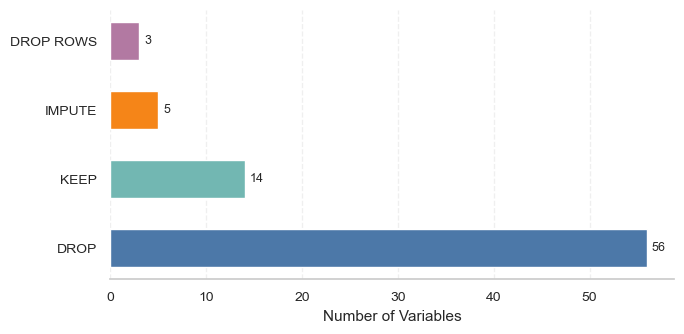

In [10]:
# Missing Data Assessment & Controlled Treatment
sns.set_style('whitegrid')

audit_table = (
    accepted_df_model
    .isna()
    .mean()
    .mul(100)
    .rename('missing_pct')
    .to_frame()
    .reset_index()
    .rename(columns = {'index': 'column_name'})
)

def assign_action(pct):
    
    if pct == 0:
        return 'KEEP'
    elif pct <= 1:
        return 'DROP ROWS'
    elif pct <= 10:
        return 'REVIEW'
    else:
        return 'DROP'

audit_table['action'] = audit_table['missing_pct'].apply(assign_action)

approved_impute_vars = [
    'emp_length',
    'mort_acc',
    'open_acc',
    'total_acc',
    'num_rev_accts',
    'acc_open_past_24mths',
    'revol_util',
    'bc_util'
]

audit_table.loc[
    (audit_table['action'] == 'REVIEW') &
    (audit_table['column_name'].isin(approved_impute_vars)),
    'action'
] = 'IMPUTE'

audit_table.loc[
    audit_table['action'] == 'REVIEW',
    'action'
] = 'DROP'

audit_table = audit_table.sort_values(
    'missing_pct',
    ascending = False
).reset_index(drop = True)

# Visualization
action_order = ['DROP', 'KEEP', 'IMPUTE', 'DROP ROWS']
action_counts = (
    audit_table['action']
    .value_counts()
    .reindex(action_order)
    .dropna()
)

fig, ax = plt.subplots(figsize = (7, 3.5))

color_map = {
    'DROP': '#4C78A8',
    'KEEP': '#72B7B2',
    'IMPUTE': '#F58518',
    'DROP ROWS': '#B279A2'
}

bars = ax.barh(
    action_counts.index,
    action_counts.values,
    color = [color_map[a] for a in action_counts.index],
    height = 0.55
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va = 'center',
        fontsize = 9
    )

ax.set_xlabel('Number of Variables', fontsize = 11)
ax.set_ylabel('')
ax.tick_params(axis = 'both', labelsize = 10)
ax.grid(axis = 'x', linestyle = '--', alpha = 0.3)
ax.grid(axis = 'y', visible = False)
sns.despine(left = True)
plt.tight_layout()

display(HTML('<br><b>Distribution of Missing Data Actions</b>'))
plt.show()


In [11]:
# Summary Table: Variables by Action
summary_table = (
    audit_table['action']
    .value_counts()
    .rename_axis('Action')
    .reset_index(name = 'Number of Variables')
)

summary_table['Percent of Total'] = (
    summary_table['Number of Variables']
    / summary_table['Number of Variables'].sum()
    * 100
)

summary_table = summary_table.sort_values(
    by = 'Number of Variables',
    ascending = False
).reset_index(drop = True)

display(HTML('<br><b>Table 2: Preprocessing Actions for Missing Data</b>'))
display(summary_table.style.hide(axis = 'index'))


Action,Number of Variables,Percent of Total
DROP,56,71.794872
KEEP,14,17.948718
IMPUTE,5,6.410256
DROP ROWS,3,3.846154


**Table 2**

- 56 variables removed due to missing data = 71.79%
- 14 variables retained unchanged = 17.95%
-  5 variables imputed = 6.41%
-  3 variables < 1% missing data rows dropped = 3.85%


In [12]:
# Missing Data Strategy Implementation
drop_columns = audit_table.loc[
    audit_table['action'] == 'DROP', 'column_name'
].tolist()

drop_rows_columns = audit_table.loc[
    audit_table['action'] == 'DROP ROWS', 'column_name'
].tolist()

impute_columns = audit_table.loc[
    audit_table['action'] == 'IMPUTE', 'column_name'
].tolist()

accepted_df_proc = accepted_df_model.drop(columns = drop_columns)       # DROP Columns
accepted_df_proc = accepted_df_proc.dropna(subset = drop_rows_columns)  # DROP Rows

# IMPUTE Numeric & Categorical Columns
numeric_impute_cols = accepted_df_proc[impute_columns].select_dtypes(include = 'number').columns
categorical_impute_cols = accepted_df_proc[impute_columns].select_dtypes(
    include = ['object', 'category']
).columns

# Numeric: Median Imputation
for col in numeric_impute_cols:
    accepted_df_proc[col] = accepted_df_proc[col].fillna(
        accepted_df_proc[col].median()
    )

# Categorical: Explicit Missing Category
for col in categorical_impute_cols:
    accepted_df_proc[col] = accepted_df_proc[col].fillna('Missing')

# Validate No Missing Values
remaining_missing = accepted_df_proc[impute_columns].isna().sum()
display(HTML(f'{remaining_missing[remaining_missing > 0]}'))


### 2.4 Variable Analysis

- Numeric variables summarized using distribution statistics
- Final data model includes 15 numeric, 5 categorical, and 2 date-derived features
- Summary statistics Appendix A (Tables A1–A3)


In [13]:
# Variable Description & Summary Statistics
numeric_vars = accepted_df_proc.select_dtypes(include = ['number']).columns
categorical_vars = accepted_df_proc.select_dtypes(include = ['object', 'category']).columns
date_vars = ['issue_d', 'earliest_cr_line']
categorical_vars = [v for v in categorical_vars if v not in date_vars]

display(HTML(f"""
    <b>Variable Summary</b><br>
    
    Numeric Variables:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {len(numeric_vars)}
    </span><br>
        
    Categorical Variables:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {len(categorical_vars)}
    </span><br>
        
    Date Variables:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {len(date_vars)}
    </span>
"""))

# Numeric Variables Summary Statistics
numeric_summary = (
    accepted_df_proc[numeric_vars]
    .describe()
    .T
    .assign(
        missing_pct = accepted_df_proc[numeric_vars]
        .isna()
        .mean()
        .mul(100)
    )
    .sort_values('missing_pct', ascending = False)
    .reset_index()
    .rename(columns = {'index': 'column_name'})
)
display(HTML('<br><b>Table A1: Numeric Variables Summary Statistics</b>'))
display(numeric_summary)

categorical_vars_clean = [
    col for col in categorical_vars
    if col != 'id'
]

# Categorical Variables Summary Statistics
categorical_summary = (
    pd.DataFrame({
        'num_categories': accepted_df_proc[categorical_vars_clean].nunique(),
        'missing_pct': (
            accepted_df_proc[categorical_vars_clean]
            .isna()
            .mean()
            .mul(100)
        )
    })
    .sort_values('missing_pct', ascending = False)
    .reset_index()
    .rename(columns = {'index': 'column_name'})
)

display(HTML('<br><b>Table A2: Categorical Variables Summary Statistics</b>'))
display(categorical_summary)


# Date Variables Summary Statistics
date_summary = (
    pd.DataFrame({
        'missing_pct': accepted_df_proc[date_vars]
        .isna()
        .mean()
        .mul(100),
        'num_unique_values': accepted_df_proc[date_vars].nunique()
    })
    .reset_index()
    .rename(columns = {'index': 'column_name'})
)
display(HTML('<br><b>Table A3: Date Variables Summary Statistics</b>'))
display(date_summary)


,column_name,count,mean,std,min,25%,50%,75%,max,missing_pct
0,annual_inc,1344081.0,76255.729893,69861.125450,16.0,45900.0,65000.00,90000.00,10999200.0,0.0
1,dti,1344081.0,18.285228,11.161156,-1.0,11.8,17.62,24.06,999.0,0.0
2,fico_range_low,1344081.0,696.173326,31.844610,630.0,670.0,690.00,710.00,845.0,0.0
3,fico_range_high,1344081.0,700.173464,31.845256,634.0,674.0,694.00,714.00,850.0,0.0
4,open_acc,1344081.0,11.598735,5.472084,1.0,8.0,11.00,14.00,90.0,0.0
5,pub_rec,1344081.0,0.215409,0.602064,0.0,0.0,0.00,0.00,86.0,0.0
6,revol_bal,1344081.0,16252.741275,22314.295190,0.0,5951.0,11140.00,19760.00,2904836.0,0.0
7,revol_util,1344081.0,51.811529,24.519966,0.0,33.4,52.20,70.70,892.3,0.0
8,total_acc,1344081.0,24.986187,11.998193,2.0,16.0,23.00,32.00,176.0,0.0
9,acc_open_past_24mths,1344081.0,4.670187,3.132995,0.0,2.0,4.00,6.00,64.0,0.0


,column_name,num_categories,missing_pct
0,emp_length,12,0.0
1,home_ownership,6,0.0
2,purpose,14,0.0
3,addr_state,51,0.0


,column_name,missing_pct,num_unique_values
0,issue_d,0.0,138
1,earliest_cr_line,0.0,739


**Tables A1–3**

- Table A1: summary statistics for numeric variables
- Table A2: summary statistics for categorical variables
- Table A3: summary statistics for date variables


#### 2.4.2 Numeric Predictors

- Numeric variables evaluated based on distribution and scale
- DTI filtered to 0-40% range (records outside removed)
- Common practice to set DTI thresholds between 30–40%
- Revolving utilization capped at 100%
- Limit the impact of outliers and maintain consistent interpretation of utilization
- Count variables (e.g., open accounts, public records, tax liens) unchanged
- Default rate ~20%, indicating moderate but expected class imbalance


In [14]:
# DTI: Remove Records > 40%
n_before = accepted_df_proc.shape[0]

accepted_df_proc = accepted_df_proc.loc[
    (accepted_df_proc['dti'] >= 0) & (accepted_df_proc['dti'] <= 40)
].copy()

n_after = accepted_df_proc.shape[0]

# Revolving Utilizaiton: Capped @ 100%
n_revol_util_gt_100 = (accepted_df_proc['revol_util'] > 100).sum()

accepted_df_proc.loc[
    accepted_df_proc['revol_util'] > 100, 'revol_util'
] = 100

display(HTML(f"""</br>
    DTI Records Removed: 
    
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {n_before - n_after:,}
    </span></br>

    Utilization Records Capped: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {n_revol_util_gt_100:,}
    </span>
"""))


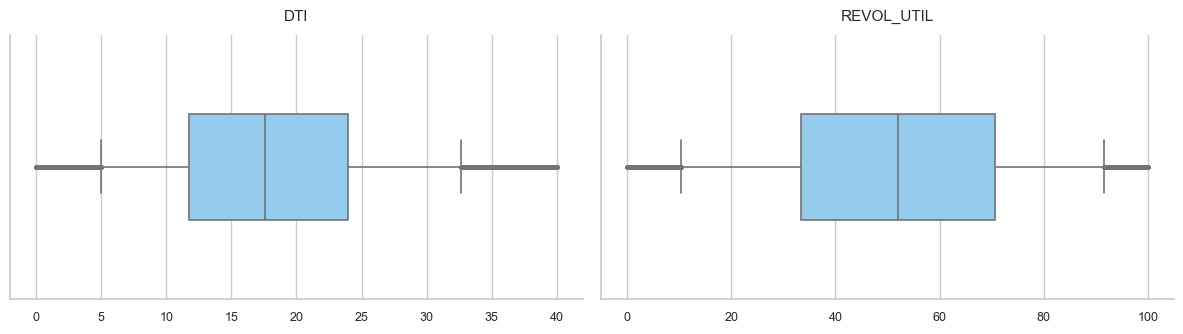

In [15]:
# Box Plots: Distribution & Skewness of Key Credit Risk Predictors
selected_vars = ['dti', 'revol_util']
sns.set_style('whitegrid')

fig, axes = plt.subplots(
    1, 2,
    figsize = (12, 3.5),
    sharey = False
)

for ax, var in zip(axes, selected_vars):

    clean_data = accepted_df_proc[var].dropna()

    sns.boxplot(
        x = clean_data,
        ax = ax,
        color = '#87cefa',
        width = 0.4,
        whis = (5, 95),
        linewidth = 1.2,
        fliersize = 2
    )

    ax.set_title(var.upper(), fontsize = 11, pad = 10)
    ax.set_xlabel('')
    ax.tick_params(axis = 'x', labelsize = 9)
    ax.tick_params(axis = 'y', left = False)

    sns.despine(ax = ax)

plt.tight_layout()

display(HTML('<br><b>Distribution & Skewness of Key Credit Risk Predictors</b>'))
plt.show()


#### 2.4.2 Categorical Predictors

- Treated ordered variables (e.g., employment length) as ordinal, others as categorical
- Simplified high-cardinality variables to reduce complexity


#### 2.4.3 Time-Based Variable Assessment & Credit Age Construction

- Converted loan issue date to datetime for chronological ordering and validation
- Derived credit age as number of months from earliest credit line to loan issue date


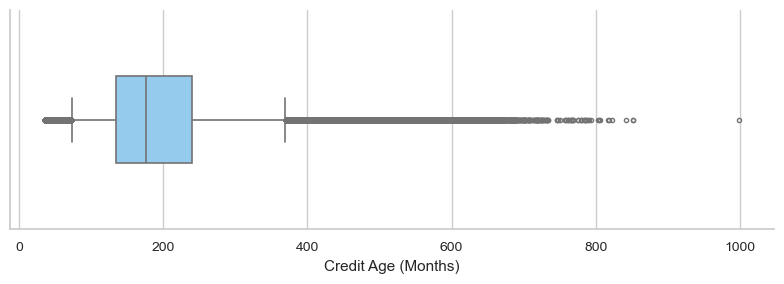

In [16]:
# Date Variable Processing: Earliest Credit Line » Credit Age
if {'issue_d', 'earliest_cr_line'}.issubset(accepted_df_proc.columns):

    accepted_df_proc['issue_d'] = pd.to_datetime(
        accepted_df_proc['issue_d'], format = '%b-%Y', errors = 'coerce'
    )

    accepted_df_proc['earliest_cr_line'] = pd.to_datetime(
        accepted_df_proc['earliest_cr_line'], format = '%b-%Y', errors = 'coerce'
    )

    accepted_df_proc['credit_age_months'] = (
        (accepted_df_proc['issue_d'].dt.year - accepted_df_proc['earliest_cr_line'].dt.year) * 12 +
        (accepted_df_proc['issue_d'].dt.month - accepted_df_proc['earliest_cr_line'].dt.month)
    )

    accepted_df_proc.loc[
        accepted_df_proc['credit_age_months'] < 0, 'credit_age_months'
    ] = pd.NA

    accepted_df_proc = accepted_df_proc.drop(columns = ['earliest_cr_line'])

# Boxplot: Credit Age (Months)
if 'credit_age_months' in accepted_df_proc.columns:

    credit_age_clean = accepted_df_proc['credit_age_months'].dropna()

    plt.figure(figsize = (8, 3))

    ax = sns.boxplot(
        x = credit_age_clean,
        color = '#87cefa',
        width = 0.4,
        whis = (5, 95),
        linewidth = 1.2,
        fliersize = 3
    )

    ax.set_xlabel('Credit Age (Months)', fontsize = 11)
    ax.tick_params(axis = 'x', labelsize = 10)

    sns.despine()
    plt.tight_layout()

    display(HTML('<br><b>Figure 1: Distribution of Credit Age (Months)</b>'))
    plt.show()
    

**Figure 1**

- Credit age right-skewed, long upper tail
- Small number of borrowers with unusually long credit histories
- Most observations concentrated within relatively narrow range


#### 2.4.4 Sample Stability & Volume-Based Filtering

**Figure 2**

- Volume relatively low from 2007–2012, stabilizing above 5,000 in August 2012
- Sample restricted to loans issued after July 31, 2012 (monthly volume > 5,000)
- Reduces variability associated with low-volume months


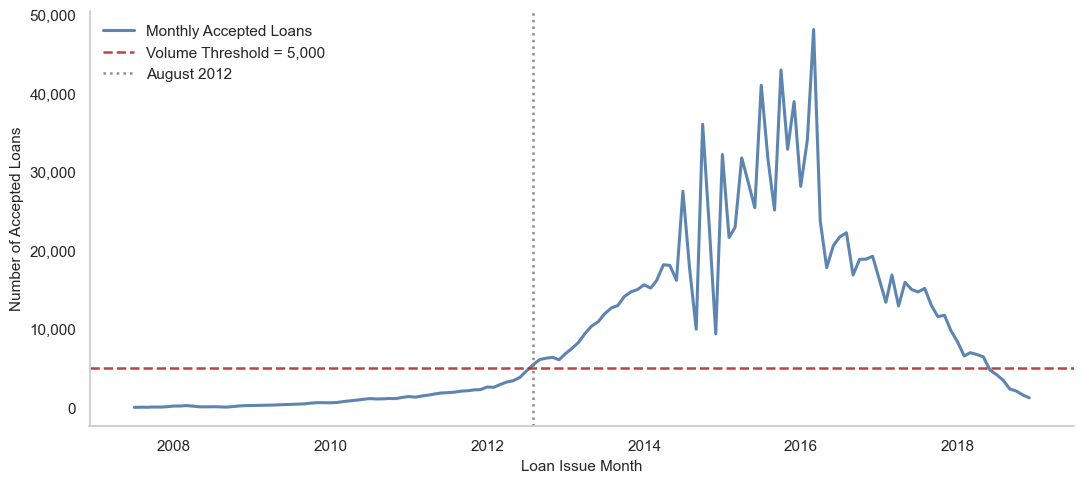

In [17]:
# Loan Volume by Year-Month » Final Dataset
accepted_df_proc['issue_d'] = pd.to_datetime(
    accepted_df_proc['issue_d'],
    format = '%b-%Y',
    errors = 'coerce'
)

monthly_counts = (
    accepted_df_proc
    .groupby(accepted_df_proc['issue_d'].dt.to_period('M'))
    .size()
    .reset_index(name = 'num_accepted_loans')
)

monthly_counts['issue_month'] = monthly_counts['issue_d'].dt.to_timestamp()

volume_threshold = 5000
first_month_ge_5000 = monthly_counts.loc[
    monthly_counts['num_accepted_loans'] >= volume_threshold, 'issue_month'
].min()

# Time Series Plot
sns.set_style('whitegrid')

plt.figure(figsize = (11, 5))
ax = plt.gca()

ax.plot(
    monthly_counts['issue_month'],
    monthly_counts['num_accepted_loans'],
    color = '#4C78A8',
    linewidth = 2.2,
    alpha = 0.9,
    label = 'Monthly Accepted Loans'
)

ax.axhline(
    y = volume_threshold,
    linestyle = '--',
    linewidth = 1.8,
    color = '#B22222',
    alpha = 0.85,
    label = f'Volume Threshold = {volume_threshold:,}'
)

ax.axvline(
    x = first_month_ge_5000,
    linestyle = ':',
    linewidth = 1.8,
    color = 'gray',
    alpha = 0.9,
    label = 'August 2012'
)

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.set_xlabel('Loan Issue Month', fontsize = 11)
ax.set_ylabel('Number of Accepted Loans', fontsize = 11)
ax.tick_params(axis = 'both', labelsize = 11)
ax.grid(False)
sns.despine()
plt.legend(loc = 'upper left', frameon = False, fontsize = 11)
plt.tight_layout()

display(HTML('<br><b>Figure 2: Monthly Accepted Loan Volume & Modeling Threshold</b>'))
plt.show()

display(HTML(f"""
    Volume Threshold:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {first_month_ge_5000.strftime('%B %Y')}
    </span><br><br>
"""))


In [18]:
# Sample Construction
accepted_df_proc['issue_d'] = pd.to_datetime(
    accepted_df_proc['issue_d'], format = '%b-%Y', errors = 'coerce'
)

# Volume-Based Sample Filter
cutoff_date = pd.Timestamp('2012-08-01')

accepted_df_final = accepted_df_proc[
    accepted_df_proc['issue_d'] >= cutoff_date
].copy()

display(HTML(f"""
    <b>Final Modeling Sample</b><br>
    
    Total Records:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {accepted_df_final.shape[0]:,}
    </span><br>
    
    Date Range:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {accepted_df_final['issue_d'].min().strftime('%Y-%m-%d')} –
        {accepted_df_final['issue_d'].max().strftime('%Y-%m-%d')}
    </span>
"""))


#### 2.4.5 Portfolio Sample Reduction

- Training on the full ~1.27M-row sample previously caused out-of-memory failures during model fitting (dense kernel expansion in the SVM approximation, parallel grid search across Random Forest/XGBoost)
- This notebook is a portfolio/demonstration piece rather than a production model, so the priority is a runnable, reproducible pipeline over squeezing marginal AUC out of the full historical volume
- Stratified random sample drawn from the volume-filtered population, preserving the original default rate
- Reduces memory pressure and runtime across every downstream model without changing any of the modeling code below


In [19]:
# Portfolio Sample Reduction
n_before = accepted_df_final.shape[0]
sample_size = 150_000

accepted_df_final, _ = train_test_split(
    accepted_df_final,
    train_size = sample_size,
    stratify = accepted_df_final['default'],
    random_state = 7
)

display(HTML(f"""
    <b>Reduced Modeling Sample</b><br>

    Sample Size:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {accepted_df_final.shape[0]:,}
    </span>
    (reduced from {n_before:,})<br>

    Default Rate:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {accepted_df_final['default'].mean():.2%}
    </span>
"""))


#### 2.4.6 Time-Based Training/Test Split

- Final (reduced) sample includes 150,000 loans; time-based split: 89,819 training (before 2016) and 60,181 test (2016 onward)
- Time-based splits commonly used to train on past loan performance before applying to newer loans to captures changes in credit conditions
- Default rate increases from 18.65% (training) to 22.38% (test)
- Credit conditions may have changed or deteriorated over time?


In [20]:
# Time-Based Training/Test Partitiioning
train_end_date = pd.Timestamp('2016-01-01')

train_df = accepted_df_final[accepted_df_final['issue_d'] < train_end_date].copy()

test_df = accepted_df_final[accepted_df_final['issue_d'] >= train_end_date].copy()

# Separate Features & Labels
label_col = 'default'
exclude_cols = ['default', 'issue_d']

X_train = train_df.drop(columns = exclude_cols)
y_train = train_df[label_col]

X_test = test_df.drop(columns = exclude_cols)
y_test = test_df[label_col]

# Sanity Checks
display(HTML(f"""
    <b>Training/Test Split Summary</b><br>
    
    Training Observations:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {X_train.shape[0]:,}
    </span><br>
        
    Test Observations:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {X_test.shape[0]:,}
    </span><br>
        
    Training Default Rate:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {y_train.mean():.2%}
    </span><br>
        
    Test Default Rate:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {y_test.mean():.2%}
    </span>
"""))


In [21]:
# Memory Management
rows = []
for name, obj in list(globals().items()):
    if not name.startswith('_'):
        try:
            size_mb = sys.getsizeof(obj) / 1e6
            rows.append((name, type(obj).__name__, size_mb))
        except:
            pass

mem_df = pd.DataFrame(rows, columns = ['variable', 'type', 'size_mb'])
mem_df = mem_df.sort_values(by = 'size_mb', ascending = False).reset_index(drop = True)

display(mem_df.head(10))


,variable,type,size_mb
0,accepted_df,DataFrame,6283.376457
1,combined_df,DataFrame,2589.846759
2,accepted_df_model,DataFrame,1373.469418
3,accepted_df_proc,DataFrame,571.563779
4,grouped_status,Series,134.023339
5,accepted_df_final,DataFrame,64.131033
6,train_df,DataFrame,38.393638
7,X_train,DataFrame,36.956534
8,test_df,DataFrame,25.737427
9,X_test,DataFrame,24.774531


In [22]:
del combined_df, accepted_df_model, accepted_df_proc


## 3.0 Exploratory Data Analysis (EDA)

- Conducted EDA to assess distributions, data quality, and relationships with default
- Numeric variables showed skewness and zero concentration » applied capping/transformation
- Strongest default drivers: credit score, utilization, debt burden
- Categorical variables showed imbalance and high cardinality » applied grouping for model stability
- Full EDA (plots, correlations, summaries) included in Appendix A


### 3.1 Predictor Diagnostics

- Training sample includes 89,819 observations with no missing values
- Dataset contains 15 numeric, 5 categorical, and 2 date variables
- Numeric variables vary widely across observations
- Categorical variables include multiple categories, with some high-cardinality

---

**Tables A4–5** 

- Table A4: summary statistics for numeric variables after preprocessing
- Table A5: summary statistics for categorical variables after preprocessing


In [23]:
# Variable Description & Summary Statistics
numeric_vars = X_train.select_dtypes(include = ['number']).columns
categorical_vars = X_train.select_dtypes(include = ['object', 'category']).columns

display(HTML(f"""
    <b>Variable Summary</b><br>
    
    Numeric Variables:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {len(numeric_vars)}
    </span><br>
        
    Categorical Variables:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {len(categorical_vars)}
    </span><br>
        
    Date Variables:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {len(date_vars)}
    </span>
"""))

# Numeric Variables Summary Statistics
numeric_summary = (
    X_train[numeric_vars]
    .describe()
    .T
    .assign(
        missing_pct = X_train[numeric_vars]
        .isna()
        .mean()
        .mul(100)
    )
    .sort_values('missing_pct', ascending = False)
    .reset_index()
    .rename(columns = {'index': 'column_name'})
)
display(HTML('<br><b>Table A4: Numeric Variables Summary Statistics (Training Sample)</b>'))
display(numeric_summary)

categorical_vars_clean = [
    col for col in categorical_vars
    if col != 'id'
]

# Categorical Variables Summary Statistics
categorical_summary = (
    pd.DataFrame({
        'num_categories': X_train[categorical_vars_clean].nunique(),
        'missing_pct': (
            X_train[categorical_vars_clean]
            .isna()
            .mean()
            .mul(100)
        )
    })
    .sort_values('missing_pct', ascending = False)
    .reset_index()
    .rename(columns = {'index': 'column_name'})
)

display(HTML('<br><b>Table A5: Categorical Variables Summary Statistics (Training Sample)</b>'))
display(categorical_summary)


,column_name,count,mean,std,min,25%,50%,75%,max,missing_pct
0,annual_inc,89819.0,74806.044302,59050.001271,3000.0,45000.0,64400.0,90000.0,6000000.00,0.0
1,dti,89819.0,18.293000,8.250991,0.0,12.1,17.8,24.1,39.99,0.0
2,fico_range_low,89819.0,693.624066,29.834652,660.0,670.0,685.0,710.0,845.00,0.0
3,fico_range_high,89819.0,697.624244,29.835558,664.0,674.0,689.0,714.0,850.00,0.0
4,open_acc,89819.0,11.615059,5.275185,1.0,8.0,11.0,14.0,57.00,0.0
5,pub_rec,89819.0,0.207584,0.590179,0.0,0.0,0.0,0.0,40.00,0.0
6,revol_bal,89819.0,16676.736503,22738.122540,0.0,6462.0,11722.0,20422.0,2568995.00,0.0
7,revol_util,89819.0,55.022202,23.427647,0.0,37.9,55.8,73.0,100.00,0.0
8,total_acc,89819.0,25.444861,11.886160,2.0,17.0,24.0,32.0,156.00,0.0
9,acc_open_past_24mths,89819.0,4.472183,3.022077,0.0,2.0,4.0,6.0,47.00,0.0


,column_name,num_categories,missing_pct
0,emp_length,12,0.0
1,home_ownership,5,0.0
2,purpose,13,0.0
3,addr_state,49,0.0


#### 3.1.1 Numeric Predictor Distributions

- Credit score distributions concentrated within a narrow range
- Debt-to-income and utilization vary widely across observations
- Income highly right-skewed with extreme values
- Credit history shows right-skewed distribution
- Adverse indicators (e.g., tax liens) heavily concentrated near zero


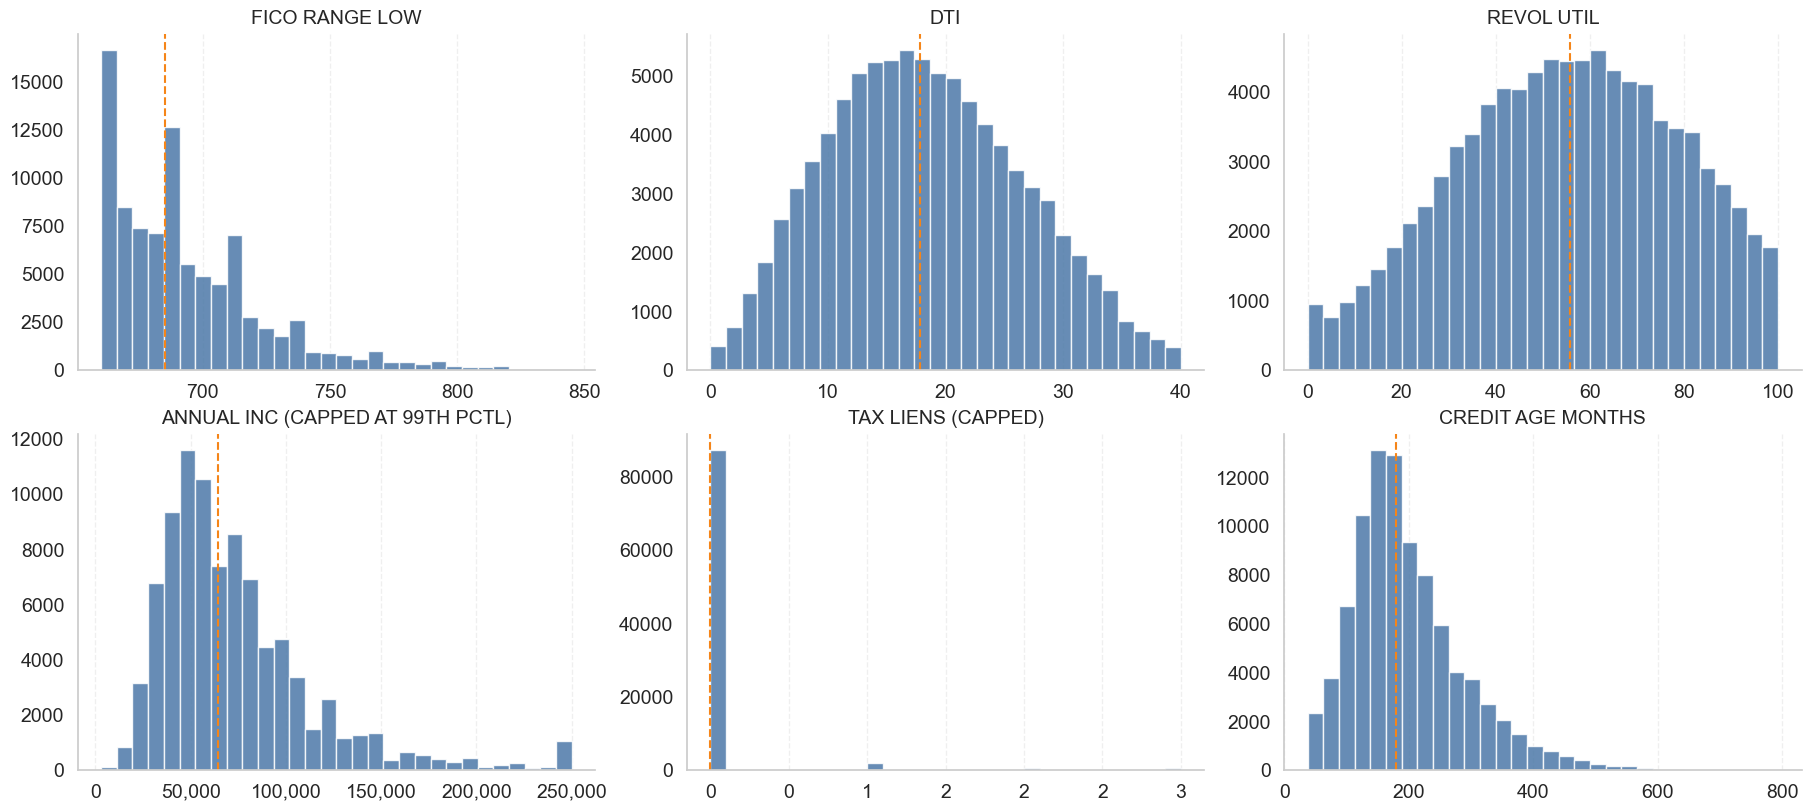

In [24]:
# Numeric Predictor Distributions
main_predictors = [
    'fico_range_low',
    'dti',
    'revol_util',
    'annual_inc',
    'tax_liens',
    'credit_age_months'
]

n_cols = 3
n_rows = math.ceil(len(main_predictors) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize = (18, 4 * n_rows),
    constrained_layout = True
)

axes = axes.flatten()

for i, var in enumerate(main_predictors):
    
    raw_data = X_train[var].dropna()

    if var == 'annual_inc':
        cap = raw_data.quantile(0.99)
        data = raw_data.clip(upper = cap)
        title_suffix = ' (CAPPED AT 99TH PCTL)'
    elif var == 'tax_liens':
        data = raw_data.clip(upper = 3)
        title_suffix = ' (CAPPED)'
    else:
        data = raw_data
        title_suffix = ''

    ax = axes[i]

    ax.hist(
        data,
        bins = 30,
        color = '#4C78A8',
        alpha = 0.85,
        edgecolor = None
    )

    median_val = data.median()
    ax.axvline(
        median_val,
        color = '#F58518',
        linestyle = '--',
        linewidth = 1.5
    )

    ax.set_title(
        var.replace('_', ' ').upper() + title_suffix,
        fontsize = 14,
        pad = 8
    )

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis = 'both', labelsize = 14)

    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

    ax.grid(axis = 'x', linestyle = '--', alpha = 0.3)
    ax.grid(axis = 'y', visible = False)

    sns.despine(ax = ax)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

display(HTML('<br><b>Figure 3: Selected Numeric Predictor Distributions (Training Sample)</b>'))
plt.show()


**Figure 3** 

- Distributions for key risk variables (credit score, DTI, utilization, income, adverse indicators, credit history)
- Patterns highlight skewness, variability, near zero concentration
- Annual income capped at 99th percentile to reduce distortion from extreme right-skew and improve distribution visibility
- Tax liens values capped to address sparsity and enhance interpretability of the distribution- Additional details Appendix A (Figure A3)

---

**Figure A3** 

- Numeric predictors show skewness, variability, and concentration patterns
- Several variables strongly right-skewed near zero
- Supports transformations and scaling for stability and interpretability


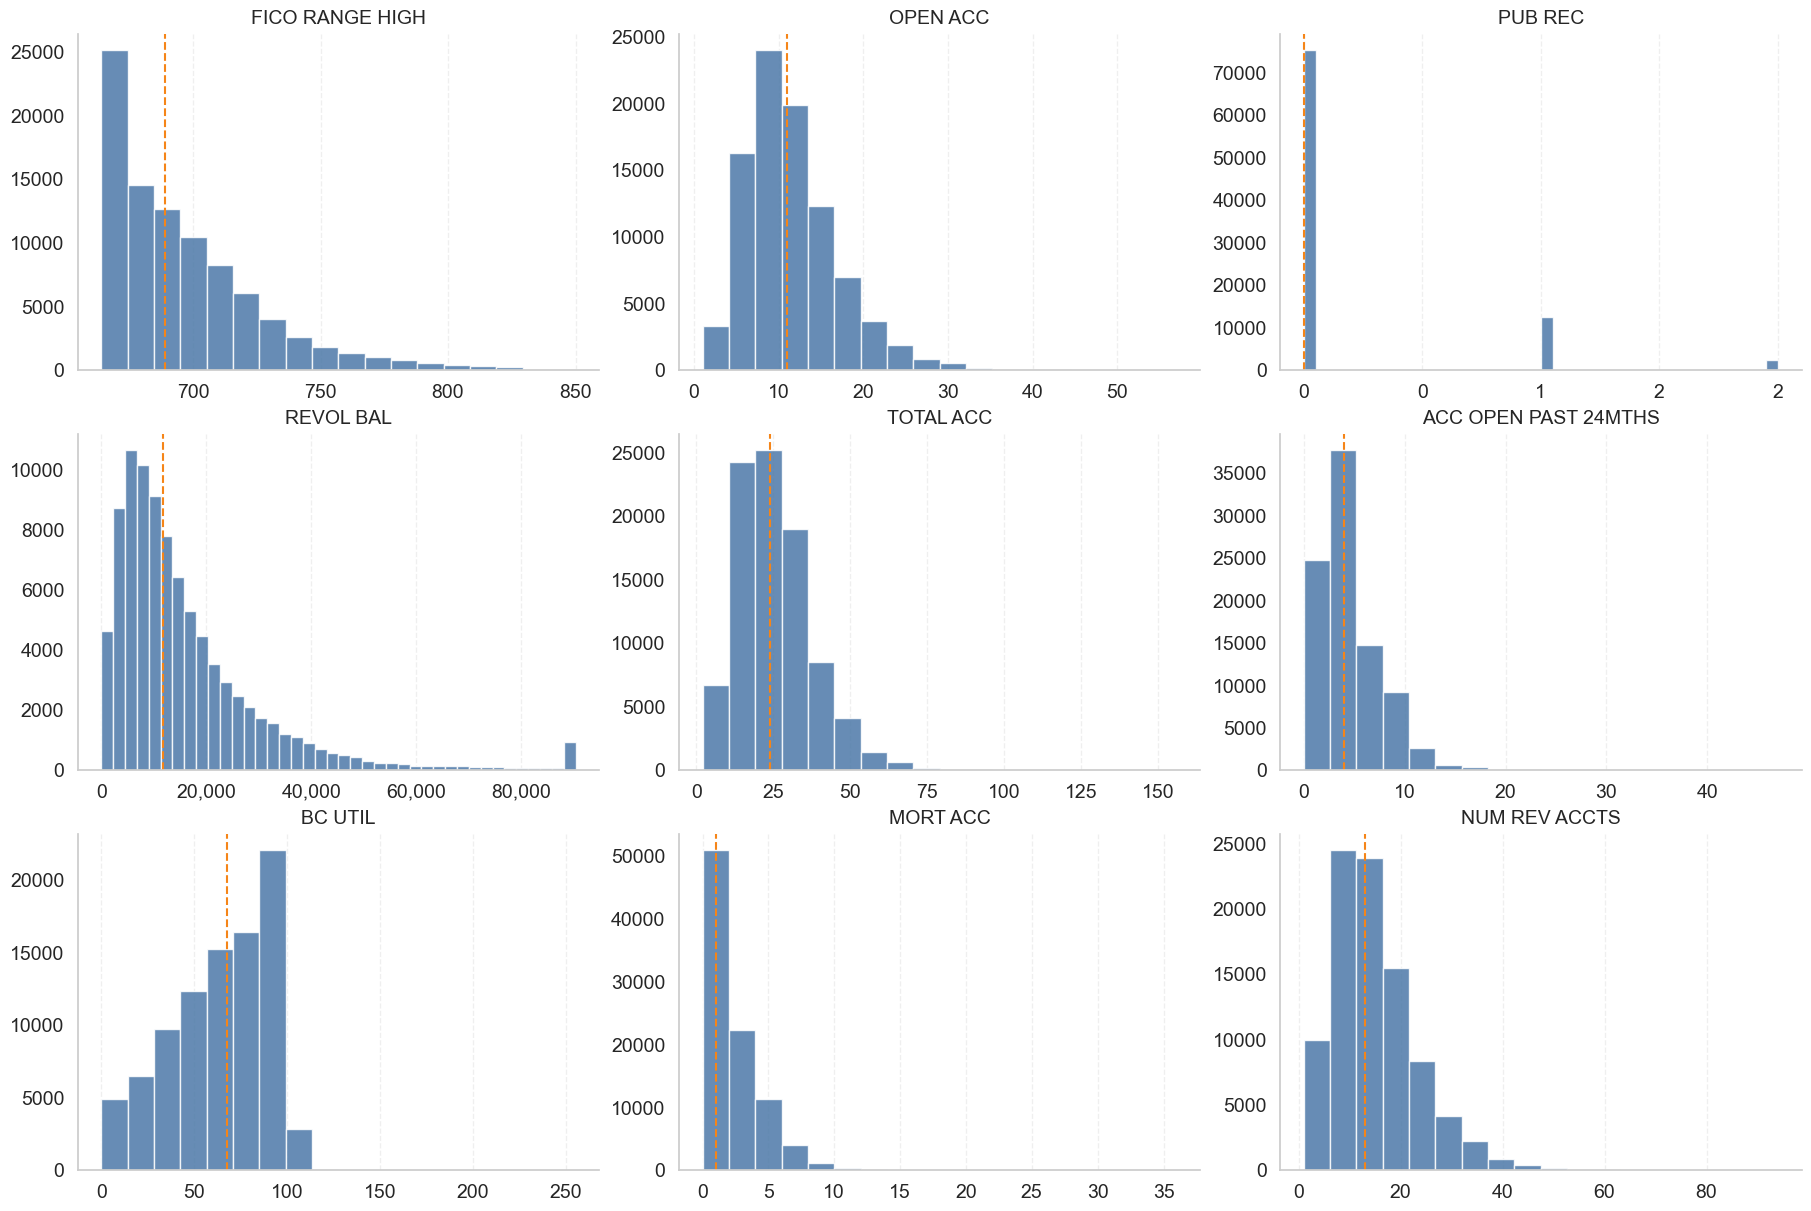

In [25]:
# Appendix A
appendix_predictors = [var for var in numeric_vars if var not in main_predictors]

n_cols = 3
n_rows = math.ceil(len(appendix_predictors) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize = (18, 4 * n_rows),
    constrained_layout = True
)

axes = axes.flatten()

for i, var in enumerate(appendix_predictors):
    
    data = X_train[var].dropna()

    if data.skew() > 5:
        upper_cap = data.quantile(0.99)
        data = data.clip(upper = upper_cap)
        bins = 40
    else:
        bins = 'sturges'

    ax = axes[i]

    ax.hist(
        data,
        bins = bins,
        color = '#4C78A8',
        alpha = 0.85,
        edgecolor = None
    )

    median_val = data.median()
    ax.axvline(
        median_val,
        color = '#F58518',
        linestyle = '--',
        linewidth = 1.5
    )

    ax.set_title(var.replace('_', ' ').upper(), fontsize = 14, pad = 8)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis = 'both', labelsize = 14)

    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

    ax.grid(axis = 'x', linestyle = '--', alpha = 0.3)
    ax.grid(axis = 'y', visible = False)

    sns.despine(ax=ax)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

display(HTML('<br><b>Figure A3: Additional Numeric Predictor Distributions (Training Sample)</b>'))
plt.show()


- Highly skewed variables were capped at the 99th percentile to reduce outlier distortion and improve visibility
- A skewness-based rule was used to apply capping consistently across predictors


#### 3.1.2 Numeric Predictor Separation by Default Class

- Credit score shows strongest separation, with lower values among defaulters
- Debt burden and utilization higher for defaulters
- Income distributions largely overlap across classes (weak signal)
- Credit history shows relatively small differences
- Sparse adverse indicators


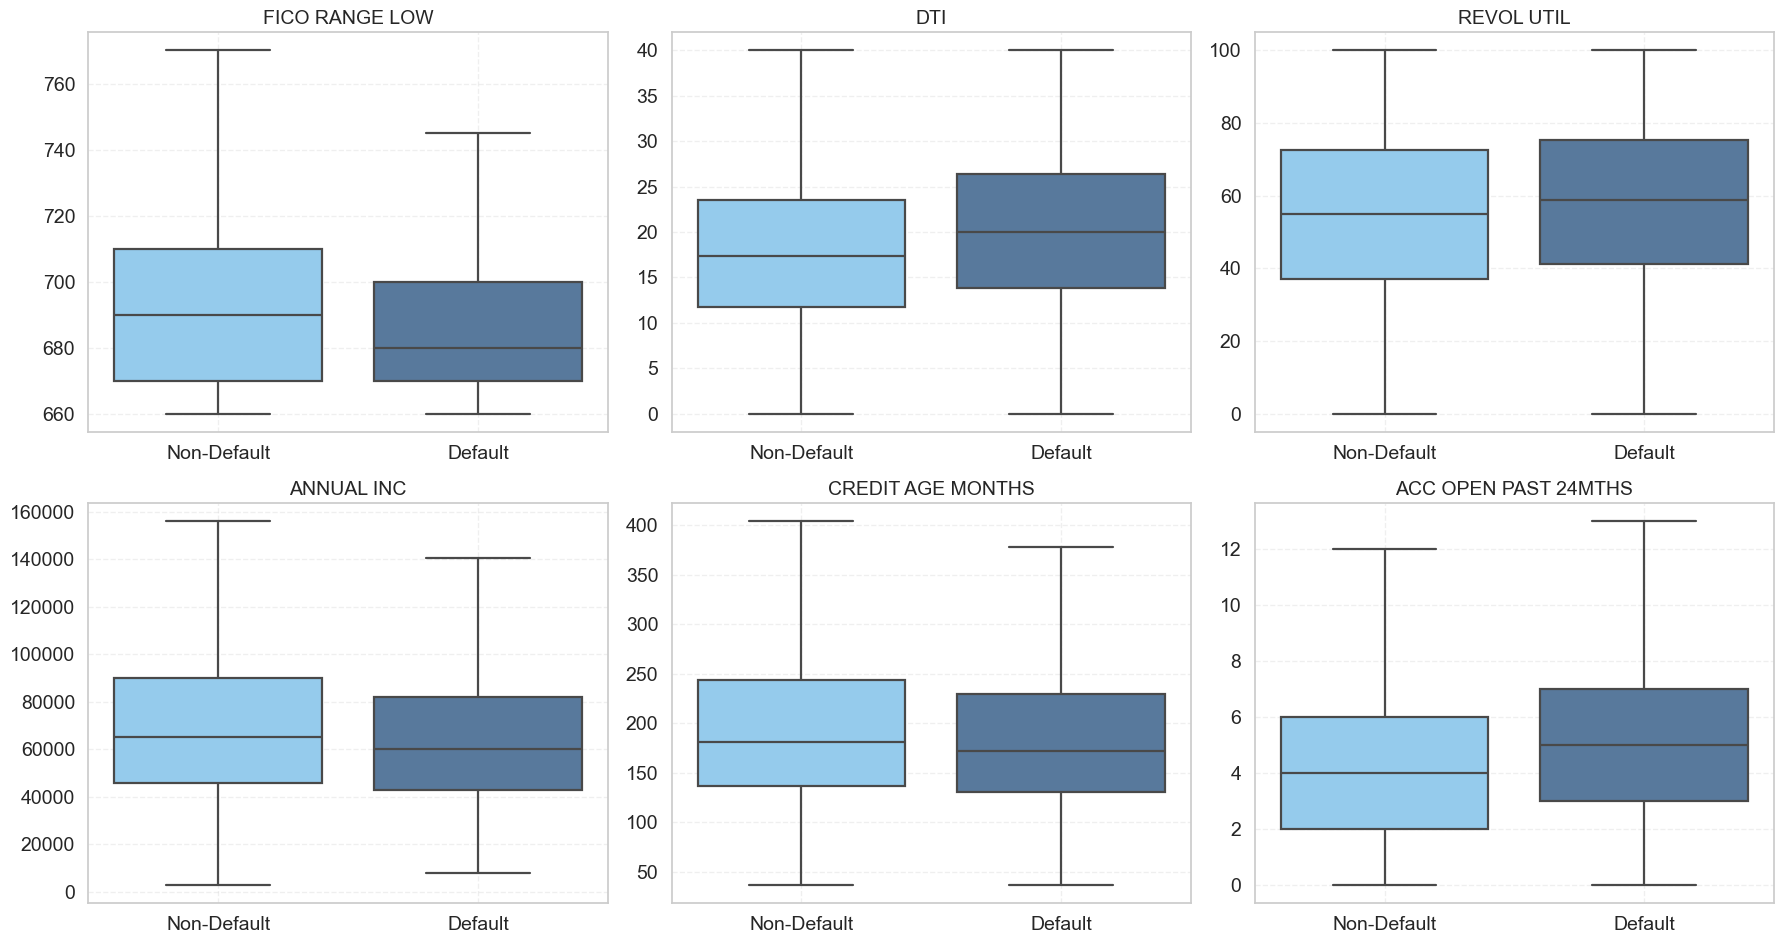

In [26]:
# Numeric Predictor Separation by Default Status
main_vars = [
    'fico_range_low',
    'dti',
    'revol_util',
    'annual_inc',
    'credit_age_months',
    'acc_open_past_24mths'
]

data = X_train.copy()
data['default_flag'] = y_train.values

cols = 3
rows = int(np.ceil(len(main_vars) / cols))

fig, axes = plt.subplots(rows, cols, figsize = (18, 5 * rows))
axes = axes.flatten()

for i, var in enumerate(main_vars):

    sns.boxplot(
        x = 'default_flag',
        y = var,
        hue = 'default_flag',
        data = data,
        palette = ('#87cefa', '#4C78A8'),
        dodge = False,
        showfliers = False,
        linewidth = 1.6,
        ax = axes[i],
        legend = False
    )

    axes[i].set_title(
        var.replace('_', ' ').upper(),
        fontsize = 14,
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Non-Default', 'Default'])

    axes[i].tick_params(axis = 'both', labelsize = 14)
    axes[i].grid(True, linestyle = '--', alpha = 0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect = [0, 0, 1, 0.96])

display(HTML('<br><b>Figure 4: Key Numeric Predictor Separation by Default Status</b>'))
plt.show()


**Figure 4** 

- Separation across default classes strongest for credit quality and leverage
- Income and credit history show greater overlap across classes (weak signal)
- Some variable distributions show asymmetry
- Additional details Appendix A (Figure A4)

---

**Figure A4** 

- Defaulters show lower credit scores, higher utilization (as expected)
- Other variables show moderate shifts between groups
- Zero-inflated features support binary treatment
- Predictive power combined across variables, not driven by single feature


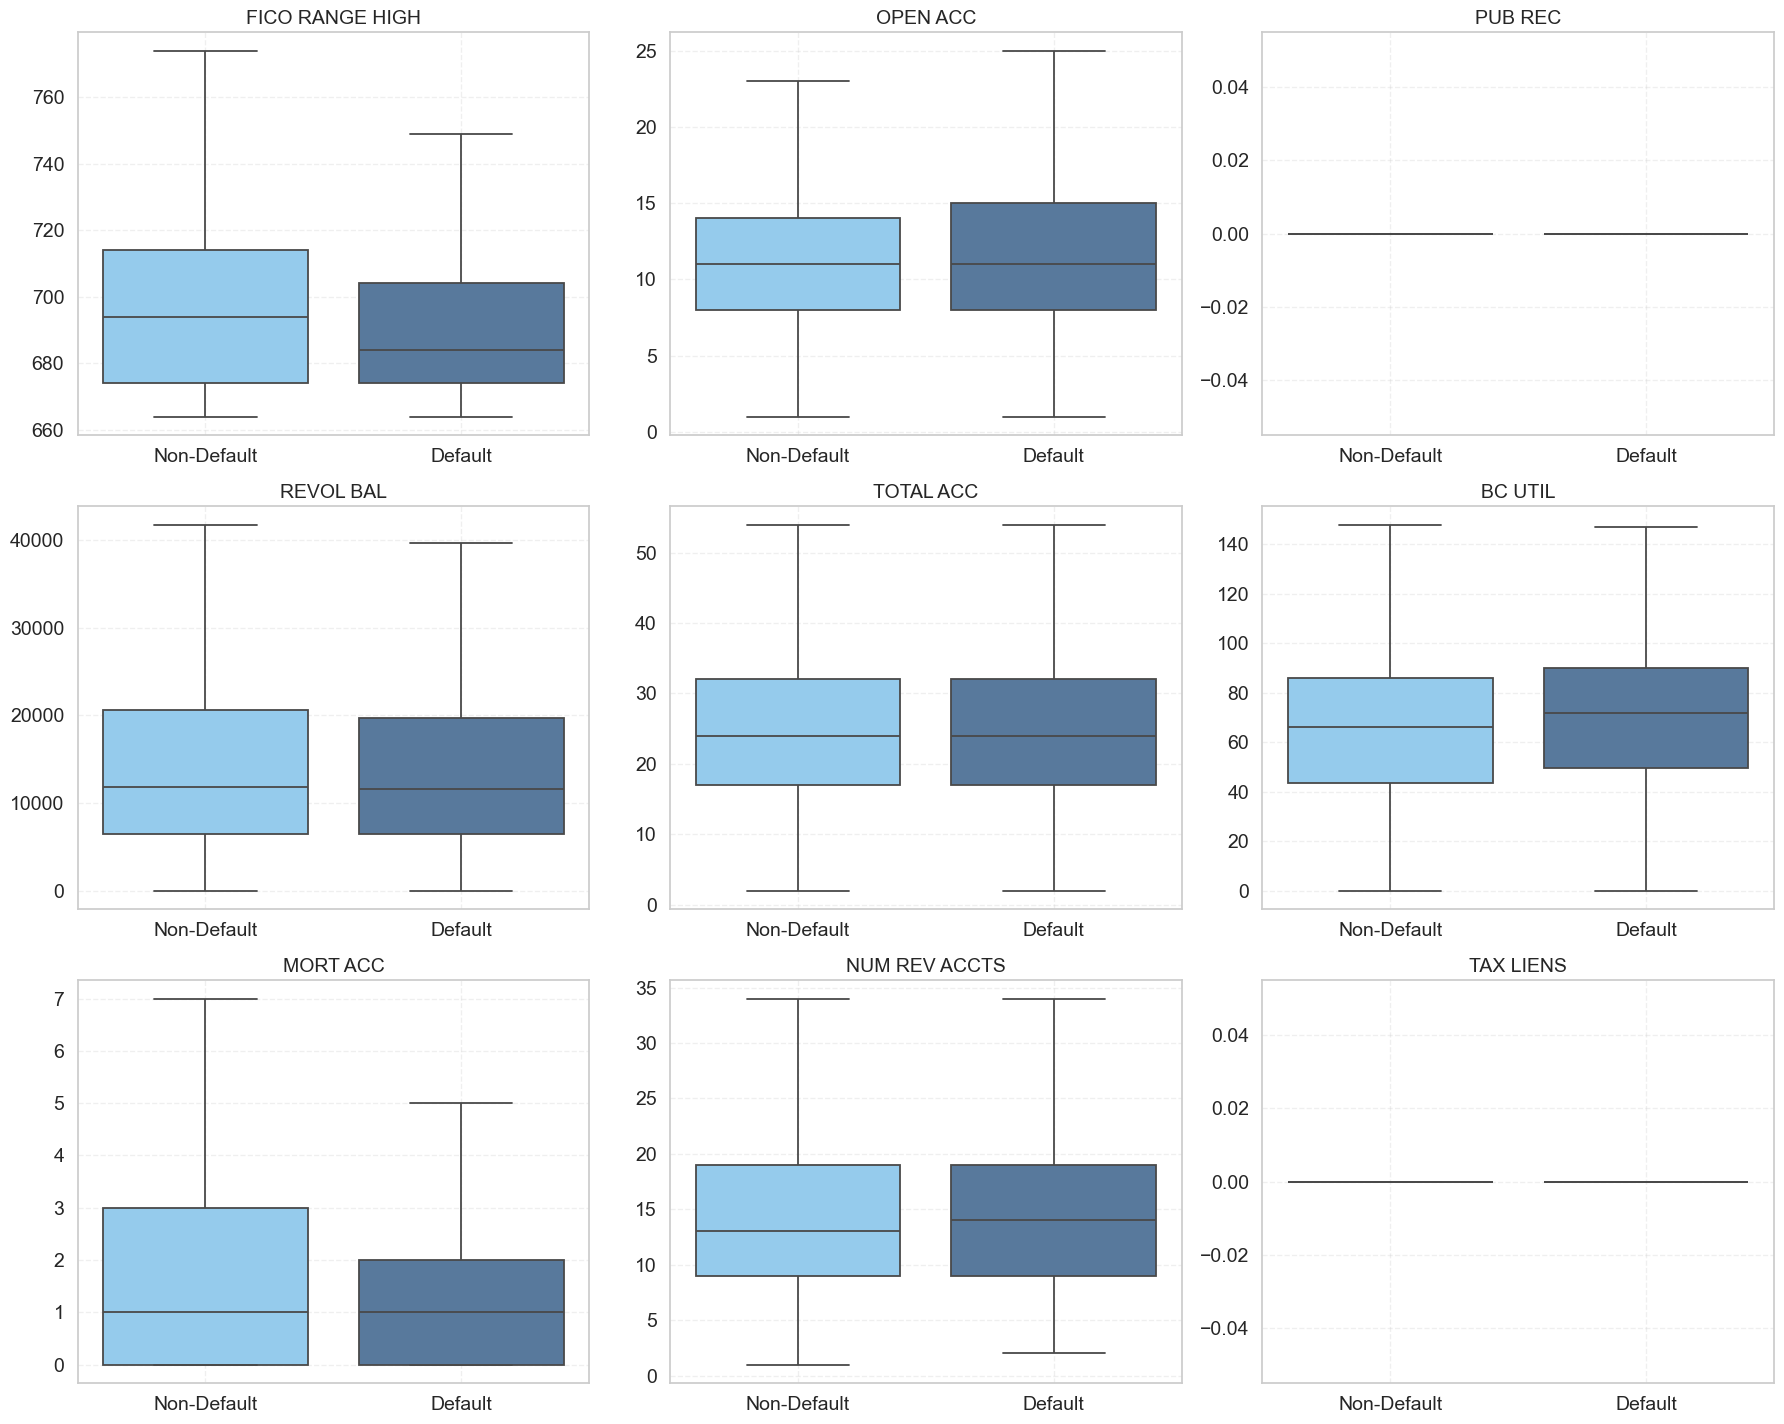

In [27]:
# Appendix A
appendix_vars = [
    v for v in X_train.select_dtypes(include = ['number']).columns
    if v not in main_vars
]

data = X_train.copy()
data['default_flag'] = y_train.values

cols = 3
rows = int(np.ceil(len(appendix_vars) / cols))

fig, axes = plt.subplots(rows, cols, figsize = (18, 5 * rows))
axes = axes.flatten()

for i, var in enumerate(appendix_vars):

    sns.boxplot(
        x = 'default_flag',
        y = var,
        hue = 'default_flag',
        data = data,
        palette = ('#87cefa', '#4C78A8'),
        dodge = False,
        showfliers = False,
        linewidth = 1.3,
        ax = axes[i],
        legend = False
    )

    axes[i].set_title(
        var.replace('_', ' ').upper(),
        fontsize = 14,
        weight = 'normal'
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Non-Default', 'Default'])

    axes[i].tick_params(axis = 'both', labelsize = 14)
    axes[i].grid(True, linestyle = '--', alpha = 0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect = [0, 0, 1, 0.96])

display(HTML('<br><b>Figure A4: Complete Numeric Predictor Separation Diagnostics</b>'))
plt.show()


#### 3.1.3 Categorical Predictor Distributions

- Categorical variables concentrated in few dominant groups
- Employment skews toward longer tenure, home ownership toward mortgage and rent
- Loan purpose dominated by debt consolidation and credit card refinancing


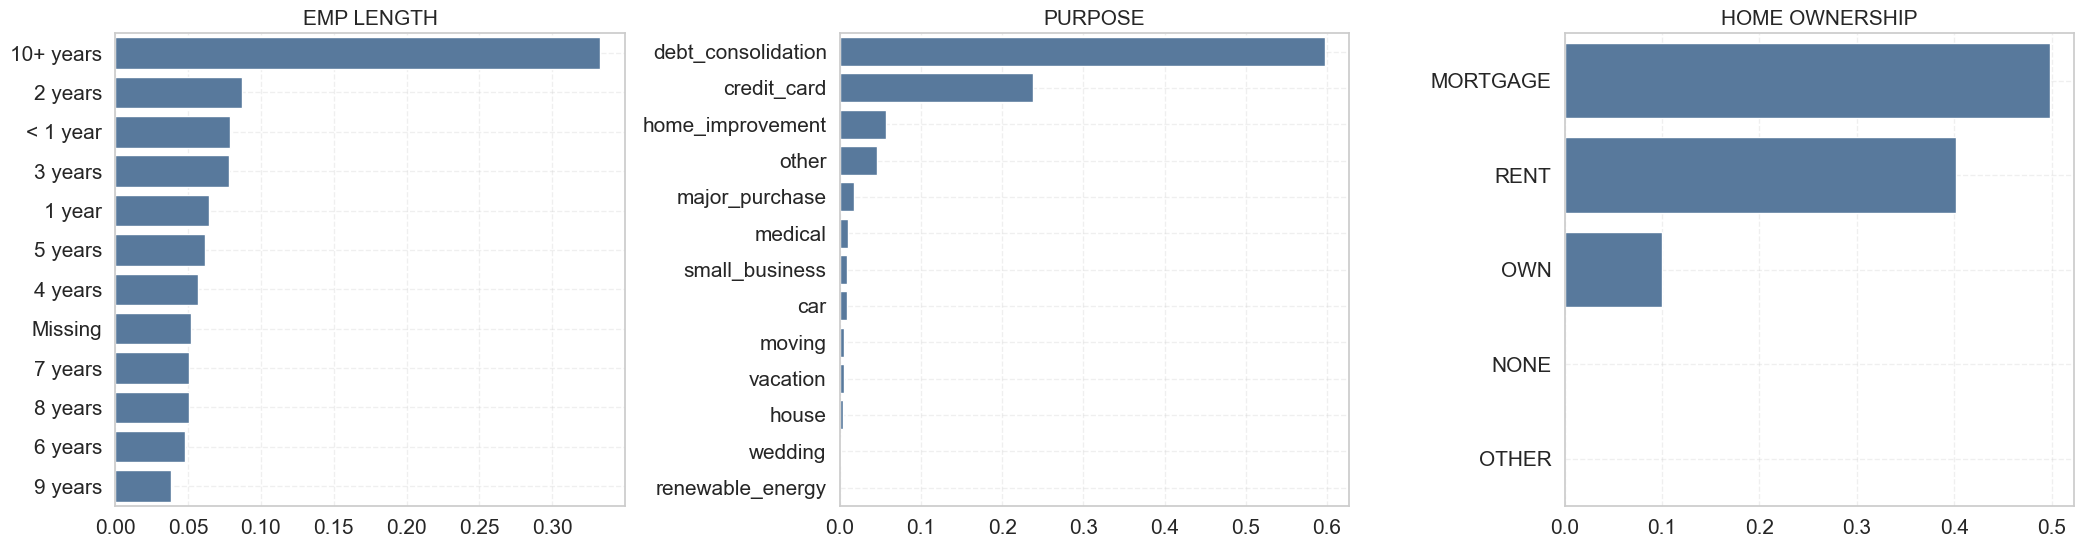

In [28]:
# Categorical Predictor Distributions
main_cat_vars = ['emp_length', 'purpose', 'home_ownership']

cols = 3
rows = int(np.ceil(len(main_cat_vars) / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize = (7 * cols, 6 * rows),
    squeeze = False
)
axes = axes.flatten()

for i, col in enumerate(main_cat_vars):

    value_counts = (
        X_train[col]
        .value_counts(normalize = True)
        .sort_values(ascending = False)
    )

    df_plot = value_counts.reset_index()
    df_plot.columns = [col, 'proportion']

    sns.barplot(
        data = df_plot,
        y = col,
        x = 'proportion',
        color = '#4C78A8',
        ax = axes[i]
    )

    axes[i].set_title(
        col.replace('_', ' ').upper(),
        fontsize = 15,
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis = 'both', labelsize = 15)
    axes[i].grid(True, linestyle = '--', alpha = 0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect = [0, 0, 1, 0.94])

display(HTML('<br><b>Figure 5: Key Categorical Predictor Distributions</b>'))
plt.show()


**Figure 5** 

- Strong concentration in key categorical groups
- Additional details Appendix A (Figure A5)

---

**Figure A5** 

- Borrowers concentrated in few large states, many smaller states grouped as “Other”
- Reflects strong imbalance across geographic categories
- Supports grouping to improve stability


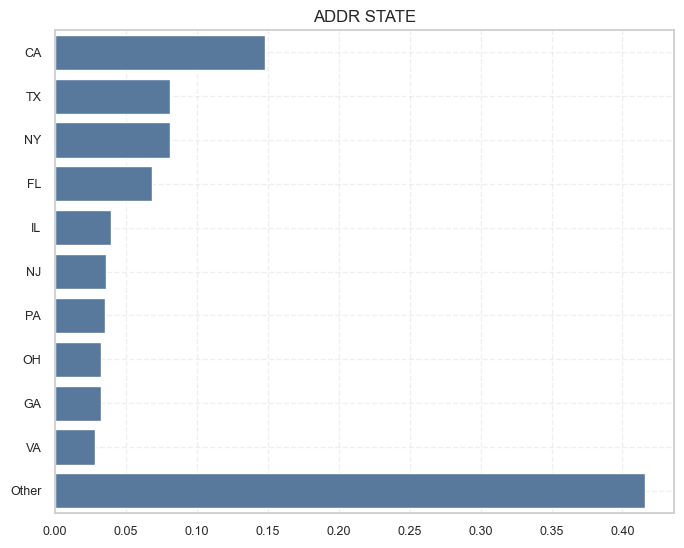

In [29]:
# Appendix A
appendix_cat_vars = ['addr_state']

cols = 1
rows = int(np.ceil(len(appendix_cat_vars) / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize = (7 * cols, 6 * rows),
    squeeze = False
)
axes = axes.flatten()

for i, col in enumerate(appendix_cat_vars):

    value_counts = (
        X_train[col]
        .value_counts(normalize = True)
        .sort_values(ascending = False)
    )

    top_n = 10
    if len(value_counts) > top_n:
        top_vals = value_counts.head(top_n)
        other_sum = value_counts.iloc[top_n:].sum()
        top_vals['Other'] = other_sum
        value_counts = top_vals

    df_plot = value_counts.reset_index()
    df_plot.columns = [col, 'proportion']

    sns.barplot(
        data = df_plot,
        y = col,
        x = 'proportion',
        color = '#4C78A8',
        ax = axes[i]
    )

    axes[i].set_title(
        col.replace('_', ' ').upper(),
        fontsize = 12,
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis = 'both', labelsize = 9)
    axes[i].grid(True, linestyle = '--', alpha = 0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect = [0, 0, 1, 0.94])

display(HTML('<br><b>Figure A5: Complete Categorical Distribution Diagnostics</b>'))
plt.show()


#### 3.1.4 Categorical Predictor Distributions by Default Class

- Non-default loans dominate most categories (75–85%)
- Default rate differences relative small but consistent across categories


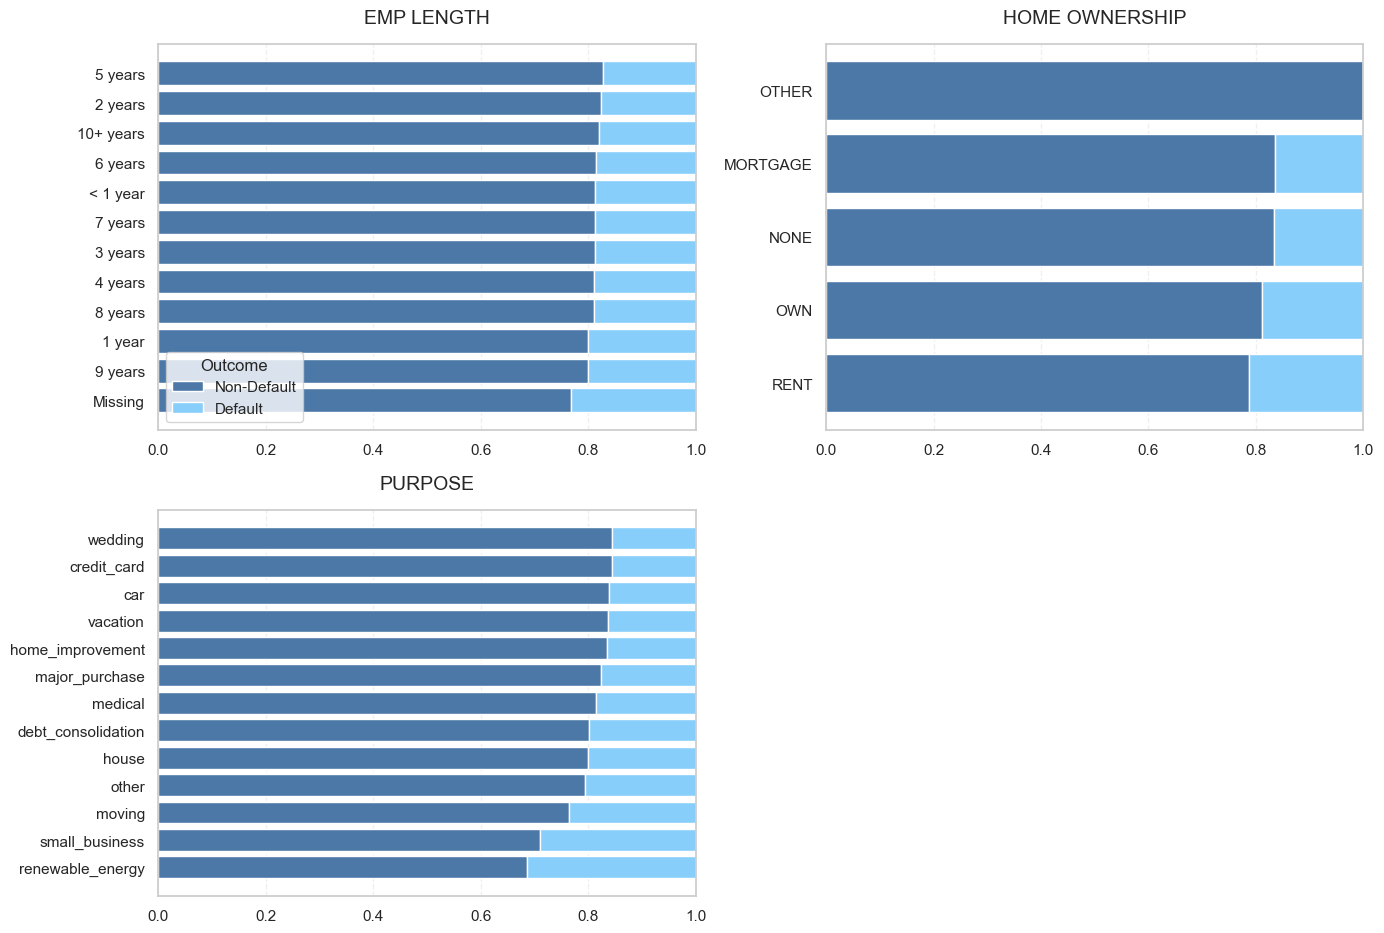

In [30]:
# Categorical Predictor Distributions by Default
main_cat_vars = ['emp_length', 'home_ownership', 'purpose']

cols = 2
rows = math.ceil(len(main_cat_vars) / cols)

fig, axes = plt.subplots(rows, cols, figsize = (7 * cols, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(main_cat_vars):

    ct = pd.crosstab(
        X_train[col],
        y_train,
        normalize = 'index'
    ).sort_values(by = 0, ascending = True)

    categories = ct.index.astype(str)
    non_default = ct[0].values
    default = ct[1].values

    y = range(len(categories))

    axes[i].barh(
        y,
        non_default,
        color = '#4C78A8',
        label = 'Non-Default'
    )

    axes[i].barh(
        y,
        default,
        left = non_default,
        color = '#87cefa',
        label = 'Default'
    )

    axes[i].set_yticks(y)
    axes[i].set_yticklabels(categories, fontsize=11)

    axes[i].set_title(
        col.replace('_', ' ').upper(),
        fontsize = 14,
        pad = 15
    )

    axes[i].set_xlim(0, 1)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis = 'x', labelsize = 11)

    axes[i].grid(axis = 'x', linestyle = '--', alpha = 0.3)

    if i == 0:
        axes[i].legend(title = 'Outcome', loc = 'lower left', frameon = True)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect = [0, 0, 1, 0.95])

display(HTML('<br><b>Figure 6: Key Categorical Predictor Distributions by Default</b>'))
plt.show()


**Figure 6** 

- Default rate differences across categories relatively small
- Employment length shows limited separation
- Home ownership and loan purpose show greater separation across categories
- Additional details Appendix A (Figure A6)

---

**Figure A6** 

- Default rates variance relatively small across states
- Smaller states show higher volatility due to limited data
- Geographic effects add incremental predictive signal
- Supports grouping for stability


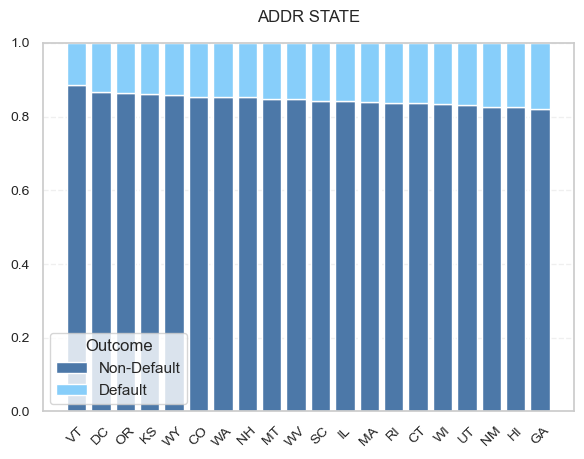

In [31]:
# Appendix A
appendix_cat_vars = ['addr_state']

cols = 1
rows = 1

fig, axes = plt.subplots(rows, cols, figsize =(6 * cols, 5))

if cols == 1:
    axes = [axes]

for i, col in enumerate(appendix_cat_vars):

    ct = pd.crosstab(
        X_train[col],
        y_train,
        normalize = 'index'
    ).sort_values(by = 0, ascending = False)

    top_n = 20
    ct = ct.head(top_n)

    categories = ct.index.astype(str)
    non_default = ct[0].values
    default = ct[1].values

    axes[i].bar(
        categories,
        non_default,
        color = '#4C78A8',
        label = 'Non-Default'
    )

    axes[i].bar(
        categories,
        default,
        bottom = non_default,
        color = '#87cefa',
        label = 'Default'
    )

    axes[i].set_title(
        col.replace('_', ' ').upper(),
        fontsize = 12,
        weight = 'normal',
        pad = 15
    )

    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis = 'x', rotation = 45, labelsize = 10)
    axes[i].tick_params(axis = 'y', labelsize = 10)
    axes[i].grid(True, linestyle = '--', alpha = 0.3)

    if i == 0:
        axes[i].legend(title = 'Outcome', loc = 'lower left', frameon = True)

plt.tight_layout(rect = [0, 0, 1, 0.95])

display(HTML('<br><b>Figure A6: Complete Categorical Default Diagnostics</b>'))
plt.show()


### 3.2 Risk Diagnostics

- Evaluated predictors for distribution, skewness, sparsity, and redundancy
- Tax liens and public records are zero-inflated but associated with higher default risk


#### 3.2.1 Tax Liens & Default Behavior

- Tax liens highly right-skewed, 96.86% reporting none
- Any lien associated with higher default risk
- Binary encoding improves stability and interpretability


In [32]:
# Tax Liens Collapsed & Default Behavior
X_train_with_target = X_train.assign(default = y_train)

X_train_with_target['has_tax_lien'] = (
    X_train_with_target['tax_liens'] > 0
).astype(int)

collapsed_summary = (
    X_train_with_target
    .groupby('has_tax_lien')
    .agg(
        count = ('default', 'size'),
        defaults = ('default', 'sum'),
        default_rate = ('default', 'mean')
    )
    .reset_index()
)

collapsed_summary['proportion_of_total'] = (
    collapsed_summary['count'] / collapsed_summary['count'].sum()
)

collapsed_summary = collapsed_summary[
    ['has_tax_lien', 'count', 'proportion_of_total', 'defaults', 'default_rate']
]

display(HTML('<br><b>Table 3: Tax Liens Collapsed & Default Behavior</b>'))
display(collapsed_summary)


,has_tax_lien,count,proportion_of_total,defaults,default_rate
0,0,86996,0.96857,16160,0.185756
1,1,2823,0.03143,588,0.208289


**Table 3** 

- 96.86% have no tax liens and 3.14% have at least one
- Lien-positive borrowers show higher default risk (20.83% vs 18.58%)
- Results are summarized using a binary indicator
- Additional details Appendix A (Table A3)

---

**Table A6** 

- Tax liens highly right-skewed with 96.86% of borrowers reporting none
- Presence of any lien increases default risk
- Higher counts add little signal due to sparsity
- Supports binary specification for stability and interpretability


In [33]:
# Tax Liens & Default Behavior
tax_liens_summary = (
    X_train
    .assign(default = y_train)
    .groupby('tax_liens')
    .agg(
        count = ('default', 'size'),
        defaults = ('default', 'sum'),
        default_rate = ('default', 'mean')
    )
    .reset_index()
    .sort_values('tax_liens')
)

tax_liens_summary['proportion_of_total'] = (
    tax_liens_summary['count'] / tax_liens_summary['count'].sum()
)

tax_liens_summary = tax_liens_summary[
    ['tax_liens', 'count', 'proportion_of_total', 'defaults', 'default_rate']
]

display(HTML('<br><b>Table A6: Tax Liens & Default Behavior</b>'))
display(tax_liens_summary.head(10))


,tax_liens,count,proportion_of_total,defaults,default_rate
0,0.0,86996,0.968570,16160,0.185756
1,1.0,1952,0.021733,412,0.211066
2,2.0,500,0.005567,105,0.210000
3,3.0,188,0.002093,41,0.218085
4,4.0,80,0.000891,15,0.187500
5,5.0,41,0.000456,5,0.121951
6,6.0,27,0.000301,4,0.148148
7,7.0,9,0.000100,2,0.222222
8,8.0,7,0.000078,1,0.142857
9,9.0,6,0.000067,1,0.166667


#### 3.2.2 Public Records & Default Behavior

- Public records sparse, most borrowers reporting none
- Any record associated with higher default risk
- Binary encoding improves stability and interpretability


In [34]:
# Public Records Collapsed & Default Behavior
X_train['has_pub_rec'] = (X_train['pub_rec'] > 0).astype(int)

pubrec_binary = (
    X_train
    .assign(default = y_train)
    .groupby('has_pub_rec')
    .agg(
        count = ('has_pub_rec', 'size'),
        defaults = ('default', 'sum')
    )
    .assign(default_rate = lambda df: df['defaults'] / df['count'])
    .reset_index()
)

pubrec_binary['proportion_of_total'] = (
    pubrec_binary['count'] /
    pubrec_binary['count'].sum()
)

pubrec_binary = pubrec_binary[
    ['has_pub_rec', 'count', 'proportion_of_total', 'defaults', 'default_rate']
]

display(HTML('<br><b>Table 4: Public Records Collapsed & Default Behavior</b>'))
display(pubrec_binary)


,has_pub_rec,count,proportion_of_total,defaults,default_rate
0,0,75104,0.836171,13643,0.181655
1,1,14715,0.163829,3105,0.211009


**Table 4** 

- 83.62% have no public records, 16.38% have at least one
- Higher default risk with records (21.10% vs 18.17%)
- Additional details Appendix A (Table A4)

---

**Table A7** 

- Public records highly right-skewed with 83.62% borrowers reporting none
- Presence of any record associated with higher default risk
- Higher counts add little signal due to sparsity
- Supports binary encoding for stability and interpretability


In [35]:
# Public Records & Default Behavior
pubrec_dist = (
    X_train
    .assign(default = y_train)
    .groupby('pub_rec')
    .agg(
        count = ('pub_rec', 'size'),
        defaults = ('default', 'sum')
    )
    .assign(
        proportion_of_total = lambda df: df['count'] / df['count'].sum(),
        default_rate = lambda df: df['defaults'] / df['count']
    )
    .reset_index()
    .sort_values('pub_rec')
)

display(HTML('<br><b>Table A7: Public Records & Default Behavior</b>'))
display(pubrec_dist.head(10))


,pub_rec,count,defaults,proportion_of_total,default_rate
0,0.0,75104,13643,0.836171,0.181655
1,1.0,12364,2589,0.137655,0.209398
2,2.0,1552,345,0.017279,0.222294
3,3.0,477,110,0.005311,0.230608
4,4.0,151,29,0.001681,0.192053
5,5.0,79,17,0.000880,0.215190
6,6.0,42,8,0.000468,0.190476
7,7.0,19,3,0.000212,0.157895
8,8.0,10,1,0.000111,0.100000
9,9.0,5,1,0.000056,0.200000


In [36]:
# Memory Management
rows = []
for name, obj in list(globals().items()):
    if not name.startswith('_'):
        try:
            size_mb = sys.getsizeof(obj) / 1e6
            rows.append((name, type(obj).__name__, size_mb))
        except:
            pass

mem_df = pd.DataFrame(rows, columns = ['variable', 'type', 'size_mb'])
mem_df = mem_df.sort_values(by = 'size_mb', ascending = False).reset_index(drop = True)

display(mem_df.head(10))


,variable,type,size_mb
0,accepted_df,DataFrame,6283.376457
1,grouped_status,Series,134.023339
2,accepted_df_final,DataFrame,64.131033
3,train_df,DataFrame,38.393638
4,X_train_with_target,DataFrame,38.393638
5,data,DataFrame,37.675086
6,X_train,DataFrame,37.675086
7,test_df,DataFrame,25.737427
8,X_test,DataFrame,24.774531
9,clean_data,Series,21.397072


## 4.0 Model Specification

- Credit age defined as months between origination and earliest credit line
- Provides interpretable measure of credit tenure
- Original date variable removed to avoid redundancy


### 4.1 Numeric Feature Engineering

- Converted sparse count variables (e.g., tax liens, public records) to binary indicators
- Log-transformed skewed monetary variables (income, revolving balance)
- Removed original variables to avoid redundancy
- Consolidated FICO bounds into single midpoint to reduce multicollinearity


In [37]:
# Encode: Tax Lien & Public Records
X_train['has_tax_lien'] = (X_train['tax_liens'] > 0).astype(int)
X_train['has_pub_rec'] = (X_train['pub_rec'] > 0).astype(int)

X_test['has_tax_lien'] = (X_test['tax_liens'] > 0).astype(int)
X_test['has_pub_rec'] = (X_test['pub_rec'] > 0).astype(int)

X_train = X_train.drop(columns = ['tax_liens', 'pub_rec'])
X_test = X_test.drop(columns = ['tax_liens', 'pub_rec'])

# Log Transform: Annual Income & Revolving Balance
X_train['log_annual_inc'] = np.log(X_train['annual_inc'])
X_test['log_annual_inc'] = np.log(X_test['annual_inc'])

X_train = X_train.drop(columns = ['annual_inc'])
X_test = X_test.drop(columns = ['annual_inc'])

X_train['log_revol_bal'] = np.log1p(X_train['revol_bal'])
X_test['log_revol_bal'] = np.log1p(X_test['revol_bal'])

X_train = X_train.drop(columns = ['revol_bal'])
X_test = X_test.drop(columns = ['revol_bal'])

# Create FICO midpoint
X_train['fico_mid'] = (X_train['fico_range_low'] + X_train['fico_range_high']) / 2
X_test['fico_mid'] = (X_test['fico_range_low'] + X_test['fico_range_high']) / 2

X_train = X_train.drop(columns = ['fico_range_low', 'fico_range_high'])
X_test = X_test.drop(columns = ['fico_range_low', 'fico_range_high'])


#### 4.1.1 Correlation Analysis of Numeric Predictors

- Strong correlations among utilization (0.8280) and account counts (0.7597)
- Log balance and income show moderate correlations
- FICO is negatively correlated with utilization
- Tax liens and public records add weak but incremental signal
- Correlations addressed through regularization
- Correlation matrix Appendix A (Figure A7).


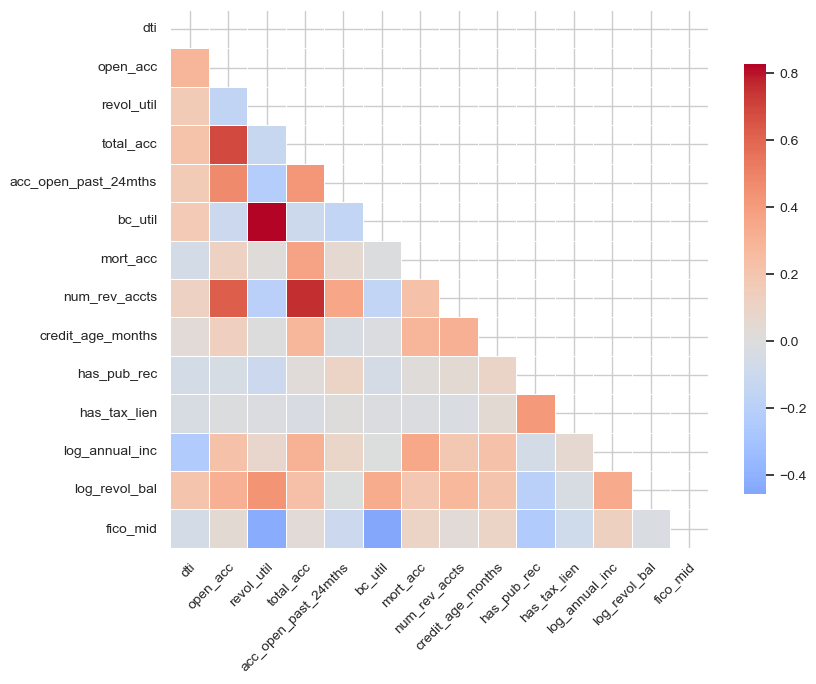

In [38]:
# Correlation Analysis of Numeric Predictors
numeric_vars = X_train.select_dtypes(include = ['number']).columns
corr_matrix = X_train[numeric_vars].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype = bool))

fig, ax = plt.subplots(figsize = (9, 7))

sns.heatmap(
    corr_matrix,
    mask = mask,
    cmap = 'coolwarm',
    center = 0,
    square = True,
    linewidths = 0.5,
    cbar_kws = {'shrink': 0.8},
    ax = ax
)

fig.canvas.draw()
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha = 'right', rotation_mode = 'anchor', fontsize = 10)
ax.set_yticklabels(ax.get_yticklabels(), rotation = 0, fontsize = 10)

if len(fig.axes) > 1:
    fig.axes[1].tick_params(labelsize = 10)

plt.tight_layout()

display(HTML('<br><b>Figure A7: Correlation Matrix of Numeric Predictors</b>'))
plt.show()


**Figure A7** 

- Correlation matrix shows moderate clusters among utilization and account variables
- No evidence of extreme multicollinearity
- Supports use of regularization to maintain stability and interpretability


In [39]:
# Highly Correlated Predictors
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool)
)

high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns = {
        'level_0': 'Predictor_1',
        'level_1': 'Predictor_2',
        0: 'Correlation'
    })
)

high_corr = high_corr[
    high_corr['Correlation'].abs() > 0.7
].sort_values(by = 'Correlation', key = abs, ascending = False)

display(HTML('<br><b>Table 5: Highly Correlated Predictors</b>'))
display(high_corr)


,Predictor_1,Predictor_2,Correlation
27,revol_util,bc_util,0.827976
39,total_acc,num_rev_accts,0.759669


**Table 5** 

- Strongest correlations occur between utilization (0.8280) and account count variables (0.7597)
- L2 regularization mitigates multicollinearity, allowing retention of informative variables


### 4.2 Categorical Feature Engineering

- Consolidated categorical variables to reduce sparsity and improve stability
- Grouped geographic indicators into four regions and collapsed low-frequency categories


In [40]:
# Region Mapping
northeast = ['CT','ME','MA','NH','RI','VT','NJ','NY','PA']
midwest = ['IL','IN','MI','OH','WI','IA','KS','MN','MO','NE','ND','SD']
south = ['DE','FL','GA','MD','NC','SC','VA','DC','WV','AL','KY','MS','TN','AR','LA','OK','TX']
west = ['AZ','CO','ID','MT','NV','NM','UT','WY','AK','CA','HI','OR','WA']

region_map = {state: 'Northeast' for state in northeast}
region_map.update({state: 'Midwest' for state in midwest})
region_map.update({state: 'South' for state in south})
region_map.update({state: 'West' for state in west})

for df in [X_train, X_test]:
    df['region'] = df['addr_state'].map(region_map).fillna('Other')
    df.drop(columns = ['addr_state'], inplace = True)

# Employment Length Mapping
emp_length_map = {
    '< 1 year': 0.5,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

for df in [X_train, X_test]:
    df['emp_length_num'] = df['emp_length'].map(emp_length_map)
    df['emp_length_missing'] = df['emp_length'].isna().astype(int)
    df['emp_length_num'] = df['emp_length_num'].fillna(0)
    df.drop(columns = ['emp_length'], inplace = True)

# Home Ownership Collapse
def collapse_home_ownership(x):
    if x in ['RENT', 'MORTGAGE', 'OWN']:
        return x
    else:
        return 'OTHER'

for df in [X_train, X_test]:
    df['home_ownership'] = df['home_ownership'].apply(collapse_home_ownership)

# Purpose Collapse
top_purposes = [
    'debt_consolidation',
    'credit_card',
    'home_improvement',
    'major_purchase',
    'small_business'
]

def collapse_purpose(x):
    
    if x in top_purposes:
        return x
    else:
        return 'other'

for df in [X_train, X_test]:
    df['purpose'] = df['purpose'].apply(collapse_purpose)


#### 4.2.1 Categorical Distribution Summary

- Categorical variables form stable, well-populated segments after consolidation
- Home ownership concentrated in Mortgage and Rent
- Loan purpose concentrted in Debt Consolidation and Credit Card
- Strong representation supports stable estimation


In [41]:
# Diagnostic Distribution
cols = ['region', 'home_ownership', 'purpose']

tables = []
for col in cols:
    vc = X_train[col].value_counts(dropna = False)
    vp = X_train[col].value_counts(normalize = True, dropna = False)

    df_col = pd.concat([vc, vp], axis = 1)
    df_col.columns = ['Count', 'Proportion']

    df_col = (
        df_col
        .reset_index()
        .rename(columns = {col: 'Category'})
        .assign(Variable = col)
        .loc[:, ['Variable', 'Category', 'Count', 'Proportion']]
    )

    tables.append(df_col)

df_diag_all = pd.concat(tables, ignore_index = True)

label_map = {
    'region': 'Region',
    'home_ownership': 'Home Ownership',
    'purpose': 'Purpose'
}

df_diag_all['Variable'] = pd.Categorical(
    df_diag_all['Variable'].map(label_map),
    categories = [label_map[c] for c in cols],
    ordered = True
)

df_diag_all = df_diag_all.sort_values(
    ['Variable', 'Proportion'],
    ascending = [True, False]
)

display(HTML("<br><b>Table A8: Categorical Distribution Summary (Training)</b>"))
display(df_diag_all.round({'Proportion': 4}))


,Variable,Category,Count,Proportion
0,Region,South,31820,0.3543
1,Region,West,24091,0.2682
2,Region,Northeast,18189,0.2025
3,Region,Midwest,15719,0.1750
4,Home Ownership,MORTGAGE,44723,0.4979
5,Home Ownership,RENT,36114,0.4021
6,Home Ownership,OWN,8971,0.0999
7,Home Ownership,OTHER,11,0.0001
8,Purpose,debt_consolidation,53707,0.5979
9,Purpose,credit_card,21336,0.2375


**Table 6**

- Categorical variables form well-populated, coherent segments
- Home ownership and loan purpose concentrated in key categories
- Representation supports stable estimation and evaluation
- Additional details Appendix A (Table A6)

---

**Table A8**

- Broad geographic distribution led by the South and West
- Home ownership is concentrated in mortgages and renters
- Loan purpose dominated by debt consolidation and credit card refinancing


#### 4.2.2  Categorical Distribution Stability Across Training & Test Samples

- Categorical distributions remain stable across training and test samples
- Minor shifts observed with no indication of feature instability


In [42]:
# Training & Test Distribution
tables = []
for col in ['region', 'home_ownership', 'purpose']:
    
    train_dist = X_train[col].value_counts(normalize = True)
    test_dist = X_test[col].value_counts(normalize = True)
    
    df_col = (
        pd.DataFrame({
            'Train_Proportion': train_dist,
            'Test_Proportion': test_dist
        })
        .fillna(0)
        .reset_index()
    )
    
    df_col.columns = ['Category', 'Train_Proportion', 'Test_Proportion']
    
    df_col['Variable'] = col
    df_col = df_col[['Variable', 'Category', 'Train_Proportion', 'Test_Proportion']]
    
    tables.append(df_col)

df_distribution_compare = (
    pd.concat(tables, ignore_index = True)
    .sort_values(['Variable', 'Category'])
)

display(HTML("<br><b>Table A8: Categorical Distribution Summary</b>"))
display(df_distribution_compare.round(4))


,Variable,Category,Train_Proportion,Test_Proportion
4,home_ownership,MORTGAGE,0.4979,0.4953
7,home_ownership,OTHER,0.0001,0.0003
6,home_ownership,OWN,0.0999,0.1236
5,home_ownership,RENT,0.4021,0.3808
9,purpose,credit_card,0.2375,0.2016
8,purpose,debt_consolidation,0.5979,0.5629
11,purpose,home_improvement,0.0564,0.0767
12,purpose,major_purchase,0.0178,0.0264
10,purpose,other,0.0811,0.1213
13,purpose,small_business,0.0093,0.0112


**Table 7**

- Categorical distributions appear stable between training and test samples
- Minor differences consistent with sampling variation
- Additional details Appendix A (Table A7)

---

**Table A8**

- Categorical distributions stable across training and test samples
- Minor differences observed in region, home ownership, and loan purpose


In [43]:
# Memory Management
rows = []
for name, obj in list(globals().items()):
    if not name.startswith('_'):
        try:
            size_mb = sys.getsizeof(obj) / 1e6
            rows.append((name, type(obj).__name__, size_mb))
        except:
            pass

mem_df = pd.DataFrame(rows, columns = ['variable', 'type', 'size_mb'])
mem_df = mem_df.sort_values(by = 'size_mb', ascending = False).reset_index(drop = True)

display(mem_df.head(10))


,variable,type,size_mb
0,accepted_df,DataFrame,6283.376457
1,grouped_status,Series,134.023339
2,accepted_df_final,DataFrame,64.131033
3,train_df,DataFrame,38.393638
4,X_train_with_target,DataFrame,38.393638
5,data,DataFrame,37.675086
6,X_train,DataFrame,32.930658
7,test_df,DataFrame,25.737427
8,X_test,DataFrame,22.074671
9,df,DataFrame,22.074671


## 5.0 Baseline Model Specification

- Uses supervised binary classification with a time-based training/test split
- L2-regularized logistic regression
- Diagnostics assess correlation, redundancy, and coefficient stability
- Evaluation uses discrimination and classification metrics commonly used for imbalanced data


### 5.1 Logistic Regression w/L2 Regularization

- Estimated logistic regression within a unified preprocessing pipeline
- L2 regularization reduces overfitting and stabilizes coefficients
- Coefficients reviewed for economic consistency


#### 5.1.1 Model Conditioning

- Logistic regression with L2 regularization
- Pipeline applied standardization for numeric features and encoding for categorical variables with a reference level omitted
- Tuned key parameters: regularization strength (C = 0.001 - 100)
- 7-fold cross-validation for hyperparameter tuning and model evaluation
- Optimized using ROC AUC due to class imbalance with best model selected with highest average validation AUC


- Results showed minimal sensitivity to C, indicating stable model behavior
- L2 regularization applied to control overfitting
- Class imbalance addressed using balanced class weights
- Findings suggest performance driven more by feature signal than hyperparameter tuning
- Optimal regularization strength C = 100 with cross-validated performance AUC = 0.6493


In [44]:
# Model Conditioning
numeric_features = X_train.select_dtypes(include = ['number']).columns
categorical_features = [
    col for col in X_train.select_dtypes(include = ['object', 'category']).columns
    if col != 'id'
]

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop = 'first', handle_unknown = 'ignore'), categorical_features)
    ]
)

# Pipeline
logit_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(
        solver = 'lbfgs',
        class_weight = 'balanced',
        max_iter = 1000
    ))
])

param_grid = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    estimator = logit_pipeline,
    param_grid = param_grid,
    cv = 7,
    scoring = 'roc_auc',
    n_jobs = 8
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print(f'Best C: {grid.best_params_['clf__C']}')
print(f'Best CV AUC: {grid.best_score_:.4f}')

ohe = best_model.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

feature_names = list(numeric_features) + list(encoded_cat_features)

coefficients = best_model.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df = coef_df.sort_values(
    by = 'Coefficient',
    key = lambda x: x.abs(),
    ascending = False
)

# Display Results
display(HTML('<br><b>Table 8: Top 10 Predictors by Absolute Coefficient Magnitude</b>'))
display(coef_df.reset_index(drop = True).round(4).head(10))


Best C: 100
Best CV AUC: 0.6493


,Feature,Coefficient
0,purpose_small_business,1.0540
1,purpose_major_purchase,0.3383
2,purpose_other,0.2903
3,acc_open_past_24mths,0.2784
4,fico_mid,-0.2779
5,purpose_home_improvement,0.2679
6,purpose_debt_consolidation,0.2467
7,dti,0.2285
8,home_ownership_RENT,0.1809
9,total_acc,-0.1714


**Table 8** 

- Loan purpose variables are the strongest predictors, led by small business loans
- Leverage and recent credit activity increase risk as expected
- Higher FICO scores and credit depth reduce risk as expected
- Borrower intent (loan purpose) and credit activity variables drive discrimination


### 5.2 Specification Diagnostics & Variable Stability

- Assessed multicollinearity, coefficient stability, and interpretability
- Focused on utilization, balances, and overlap with credit score variables
- Nested models used supported variable selection


#### 5.2.1 Multicollinearity Assessment Summary

- Elevated correlation among utilization measures (ρ ≈ 0.8280) but manageable under L2 regularization
- FICO is moderately negatively correlated with utilization
- Other relationships are moderate to weak
- The model remains stable and economically coherent as the baseline


In [45]:
# Multicollinearity Assessment Summary
cols = ['revol_util', 'log_revol_bal', 'bc_util', 'fico_mid', 'dti']

display(HTML('<br><b>Table 9: Multicollinearity Assessment Summary</b>'))
display(X_train[cols].corr().round(4))


,revol_util,log_revol_bal,bc_util,fico_mid,dti
revol_util,1.0000,0.4347,0.8280,-0.4302,0.1643
log_revol_bal,0.4347,1.0000,0.3349,-0.0215,0.2147
bc_util,0.8280,0.3349,1.0000,-0.4569,0.1743
fico_mid,-0.4302,-0.0215,-0.4569,1.0000,-0.0598
dti,0.1643,0.2147,0.1743,-0.0598,1.0000


**Table 9** 

- FICO is moderately negatively correlated with utilization
- Other relationships are moderate to weak
- Supports L2 regularization


#### 5.2.2 Revolving Utilization & Revolving Balance

- Utilization increases default risk with balance showing relatively small negative effect
- Effects persist in joint models, indicating meaningful conditional relationships
- Interaction indicates the negative balance effect weakens at higher utilization levels


In [46]:
# Revolving Utilization & Revolving Balance
base_numeric = [c for c in numeric_features if c not in ['revol_util', 'log_revol_bal']]
cat_cols = list(categorical_features)

# Model 1: util only
coefs_1, m1 = fit_logit_model(
    X_train, y_train,
    numeric_cols = base_numeric + ['revol_util'],
    cat_cols = cat_cols
)

# Model 2: balance only
coefs_2, m2 = fit_logit_model(
    X_train, y_train,
    numeric_cols = base_numeric + ['log_revol_bal'],
    cat_cols = cat_cols
)

# Model 3: util + balance
coefs_3, m3 = fit_logit_model(
    X_train, y_train,
    numeric_cols = base_numeric + ['revol_util', 'log_revol_bal'],
    cat_cols = cat_cols
)

display(HTML('<br><b>Table 10: Conditional Coefficient Behavior of Utilization & Revolving Balance</b>'))
display(pd.DataFrame({
    'util_only': coefs_1.reindex(['revol_util','log_revol_bal']),
    'bal_only':  coefs_2.reindex(['revol_util','log_revol_bal']),
    'both':      coefs_3.reindex(['revol_util','log_revol_bal'])
}).round(4))


,util_only,bal_only,both
revol_util,0.0674,NaN,0.0953
log_revol_bal,NaN,-0.0378,-0.0645


**Table 10** 

- Utilization remains the primary positive risk driver with balance retaining a negative effect
- Coefficient signs remain stable across specifications with expected weakening when jointly included
- Confirms meaningful relationships under additive specification


In [47]:
# Logistic Regression Model Pipeline
X_train_int = X_train.copy()
X_test_int = X_test.copy()

X_train_int['util_x_logbal'] = X_train_int['revol_util'] * X_train_int['log_revol_bal']
X_test_int['util_x_logbal'] = X_test_int['revol_util'] * X_test_int['log_revol_bal']

numeric_features_int = X_train_int.select_dtypes(include = ['number']).columns
categorical_features_int = X_train_int.select_dtypes(include = ['object','category']).columns

pre_int = ColumnTransformer([
    ('num', StandardScaler(), numeric_features_int),
    ('cat', OneHotEncoder(drop = 'first', handle_unknown = 'ignore'), categorical_features_int)
])

logit_int = Pipeline([
    ('preprocessor', pre_int),
    ('clf', LogisticRegression(
        C = 1.0, 
        solver = 'lbfgs', 
        class_weight = 'balanced', 
        max_iter = 2000)
    )
])

logit_int.fit(X_train_int, y_train)

print('logit_int fitted.')


logit_int fitted.


In [48]:
# Interaction Terms
num_names = list(numeric_features_int)
cat_names = list(
    logit_int.named_steps['preprocessor']
        .named_transformers_['cat']
        .get_feature_names_out(categorical_features_int)
)

feat_names = num_names + cat_names
coefs = pd.Series(
    logit_int.named_steps['clf'].coef_[0],
    index = feat_names
)

# Interaction Summary
interaction_df = (
    coefs[['revol_util', 'log_revol_bal', 'util_x_logbal']]
    .reset_index()
)
interaction_df.columns = ['interaction', 'coefficient']

display(HTML('<br><b>Table 11: Revolving Utilization, Revolving Balance, & Interaction Coefficients</b>'))
display(interaction_df.round(4))


,interaction,coefficient
0,revol_util,-0.2967
1,log_revol_bal,-0.1310
2,util_x_logbal,0.4368


**Table 11** 

- Interaction between utilization and balance indicates the negative balance effect weakens at higher utilization levels
- Captures nonlinear risk dynamics with stable coefficient estimates
- Supports retaining a simpler baseline model


#### 5.2.3 Public Records & FICO Redundancy

- Public records show a positive risk effect without FICO, but decreases and changes sign once FICO is included
- Suggests shared information with FICO absorbing most of the signal
- Variable retained for further evaluation despite limited incremental contribution


In [49]:
# Public Records & FICO Redundancy
base_num_no_fico = [c for c in numeric_features if c != 'fico_mid']
coefs_nf, _ = fit_logit_model(X_train, y_train, base_num_no_fico, list(categorical_features))
coefs_f, _ = fit_logit_model(X_train, y_train, list(numeric_features), list(categorical_features))

display(HTML('<br><b>Public Records & FICO Redundancy</b>'))
display(pd.DataFrame({
    'no_fico': coefs_nf.reindex(['has_pub_rec']),
    'with_fico': coefs_f.reindex(['has_pub_rec'])
}).round(4))


,no_fico,with_fico
has_pub_rec,0.0489,-0.0099


#### 5.2.4 Nested Specification Comparison

- Final model selected for stability, economic coherence, and scorecard suitability
- Strong generalization with minimal overfitting (training AUC 0.6502, test AUC 0.6511)
- Removing bankcard utilization or public records has minimal impact, indicating limited incremental value


In [50]:
# Model Specification & Final Baseline Selection
numeric_full = list(numeric_features)
categorical_full = list(categorical_features)

# Model A
model_A, results_A = evaluate_logit_model(
    X_train, y_train, X_test, y_test,
    numeric_full, categorical_full
)

# Model B
numeric_B = [c for c in numeric_full if c != 'bc_util']

model_B, results_B = evaluate_logit_model(
    X_train, y_train, X_test, y_test,
    numeric_B, categorical_full
)

# Model C
numeric_C = [c for c in numeric_full if c != 'has_pub_rec']

model_C, results_C = evaluate_logit_model(
    X_train, y_train, X_test, y_test,
    numeric_C, categorical_full
)

comparison = pd.DataFrame(
    [results_A, results_B, results_C],
    index = ['Full_Model', 'No_bc_util', 'No_has_pub_rec']
)

display(HTML('<br><b>Table 12: Nested Baseline Model Comparison</b>'))
display(comparison.round(4))


,Train_AUC,Test_AUC,Train_Error,Test_Error
Full_Model,0.6502,0.6511,0.1867,0.2237
No_bc_util,0.6502,0.6511,0.1867,0.2238
No_has_pub_rec,0.6502,0.6509,0.1867,0.2238


**Table 12** 

- Nested models show minimal differences in AUC and error rates
- Removing bankcard utilization or public records has almost no impact on performance


### 5.3 Baseline Model Selection & Justification

- Final baseline model selected through diagnostic refinement and nested evaluation
- Assessed for stability, multicollinearity, economic coherence, and interpretability
- Balances performance and simplicity, supporting transparent scoring and segmentation


#### 5.3.1 Final Baseline Logistic Regression

- L2-regularized logistic regression model
- Redundant variables (bankcard utilization, public records) excluded without performance loss
- Stable performance with minimal overfitting (training AUC 0.6502, test AUC 0.6511)


In [51]:
# Final Logistic Regression Baseline Model
numeric_features_final = [
    c for c in X_train.select_dtypes(include = ['number']).columns
    if c not in ['bc_util', 'has_pub_rec']
]
#display(f'Numeric: {numeric_features_final}')

categorical_features_final = [
    col for col in X_train.select_dtypes(include = ['object', 'category']).columns
    if col != 'id'
]
#display(f'Categorical: {categorical_features_final}')


In [52]:
# Logistic Regression Model Pipeline
final_preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_features_final),
        ('cat', OneHotEncoder(drop = 'first', handle_unknown = 'ignore'),
         categorical_features_final)
    ]
)

final_model = Pipeline(steps = [
    ('preprocessor', final_preprocessor),
    ('clf', LogisticRegression(
        C = 1.0,
        solver = 'lbfgs',
        class_weight = 'balanced',
        max_iter = 2000
    ))
])

final_model.fit(X_train, y_train)

print('final_model fitted.')


final_model fitted.


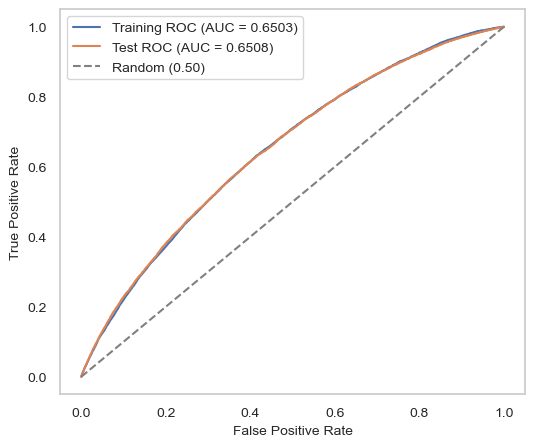

In [53]:
# Final Model Performance Metrics
train_probs = final_model.predict_proba(X_train)[:,1]
test_probs = final_model.predict_proba(X_test)[:,1]

train_auc = roc_auc_score(y_train, train_probs)
test_auc = roc_auc_score(y_test, test_probs)

train_error = 1 - accuracy_score(y_train, (train_probs >= 0.5))
test_error = 1 - accuracy_score(y_test, (test_probs >= 0.5))

# ROC Values
fpr_train, tpr_train, _ = roc_curve(y_train, train_probs)
fpr_test, tpr_test, _ = roc_curve(y_test, test_probs)

plt.figure(figsize = (6, 5))
ax = plt.gca()

plt.plot(fpr_train, tpr_train, label = f'Training ROC (AUC = {train_auc:.4f})')
plt.plot(fpr_test, tpr_test, label = f'Test ROC (AUC = {test_auc:.4f})')
plt.plot([0,1], [0,1], linestyle = '--', color = 'gray', label = 'Random (0.50)')

plt.xlabel('False Positive Rate', fontsize = 10)
plt.ylabel('True Positive Rate', fontsize = 10)
#plt.title('ROC Curve – Baseline Logistic Model')
ax.tick_params(axis = 'both', labelsize = 10)
plt.legend(fontsize = 10)
plt.grid(None)

display(HTML('<br><b>Figure 7: ROC Curve » Baseline Logistic Model</b>'))
plt.show()

display(HTML(f"""</br>
    <b>Baseline Model Performance</b></br>

    Training Error: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_error:.4}
    </span></br>

    Test Error: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_error:.4}
    </span>
"""))


**Figure 7** 

- ROC curves show stable out-of-sample discrimination
- Consistent performance (training AUC 0.6502, test AUC 0.6511) with minimal overfitting
- Smooth ROC curve indicates consistent ranking performance above random


In [54]:
# Final Model Logistic Regression Model
num_names = list(numeric_features_final)

cat_names = list(
    final_model.named_steps['preprocessor']
        .named_transformers_['cat']
        .get_feature_names_out(categorical_features_final)
)

feature_names_final = num_names + cat_names
coefficients_final = final_model.named_steps['clf'].coef_[0]

coef_df_final = pd.DataFrame({
    'Feature': feature_names_final,
    'Coefficient': coefficients_final
}).sort_values(
    by = 'Coefficient',
    key = lambda x: x.abs(),
    ascending = False
)

display(HTML('<br><b>Table 13: Top 10 Predictors by Absolute Coefficient Magnitude</b>'))
display(coef_df_final.reset_index(drop = True).round(4).head(10))

intercept_final = final_model.named_steps['clf'].intercept_[0]
display(HTML(f"""</br>
    Intercept: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {intercept_final:.4f}
    </span>
"""))


,Feature,Coefficient
0,purpose_small_business,1.0404
1,purpose_major_purchase,0.3346
2,purpose_other,0.2860
3,fico_mid,-0.2786
4,acc_open_past_24mths,0.2777
5,purpose_home_improvement,0.2614
6,purpose_debt_consolidation,0.2448
7,dti,0.2295
8,home_ownership_RENT,0.1788
9,total_acc,-0.1719


**Table 13** 

- Coefficient rankings show a consistent hierarchy of risk drivers
- Loan purpose is most influential, followed by leverage and credit activity
- Higher credit quality (e.g., FICO) reduces default risk as expected


In [55]:
# Memory Management
rows = []
for name, obj in list(globals().items()):
    if not name.startswith('_'):
        try:
            size_mb = sys.getsizeof(obj) / 1e6
            rows.append((name, type(obj).__name__, size_mb))
            
        except:
            pass

mem_df = pd.DataFrame(rows, columns = ['variable', 'type', 'size_mb'])
mem_df = mem_df.sort_values(by = 'size_mb', ascending = False).reset_index(drop = True)

display(mem_df.head(10))


,variable,type,size_mb
0,accepted_df,DataFrame,6283.376457
1,grouped_status,Series,134.023339
2,accepted_df_final,DataFrame,64.131033
3,X_train_with_target,DataFrame,38.393638
4,train_df,DataFrame,38.393638
5,data,DataFrame,37.675086
6,X_train_int,DataFrame,33.649210
7,X_train,DataFrame,32.930658
8,test_df,DataFrame,25.737427
9,X_test_int,DataFrame,22.556119


## 6.0 Baseline Discrimination & Segmentation Performance

- Evaluate the model’s ability to support practical credit risk segmentation
- Focus on score scaling, ordered stratification, and discrimination metrics
- Benchmarks performance against LendingClub’s grading system


### 6.1 Scorecard Construction & Scaling Framework

- Probabilities converted to a log-odds scorecard (base 600, 20 points to double odds)
- Training deciles applied consistently to the test set
- Default rates decline progressively across deciles in both samples
- Demonstrates strong risk separation with consistent ordering and no inversions


In [56]:
# Scorecard Construction & Scaling Framework
train_pd = best_model.predict_proba(X_train)[:, 1]
test_pd = best_model.predict_proba(X_test)[:, 1]

epsilon = 1e-6
train_pd = np.clip(train_pd, epsilon, 1 - epsilon)
test_pd = np.clip(test_pd, epsilon, 1 - epsilon)

train_odds = train_pd / (1 - train_pd)
test_odds = test_pd / (1 - test_pd)

train_log_odds = np.log(train_odds)
test_log_odds = np.log(test_odds)

# Score Scaling Parameters
base_score = 600
pdo = 20

B = pdo / np.log(2)
A = base_score

train_score = A - B * train_log_odds
test_score = A - B * test_log_odds

train_decile = pd.qcut(train_score, 10, labels = False)

cutoffs = pd.qcut(train_score, 10, retbins = True)[1]
test_decile = pd.cut(test_score, bins = cutoffs, labels = False, include_lowest = True)

# Training Summary
train_results = pd.DataFrame({
    'decile': train_decile,
    'default': y_train
})

train_summary = (
    train_results
        .groupby('decile', as_index = False)['default']
        .mean()
        .rename(columns = {'default': 'train_default_rate'})
)

# Test Summary
test_results = pd.DataFrame({
    'decile': test_decile,
    'default': y_test
})

test_summary = (
    test_results
        .groupby('decile', as_index = False)['default']
        .mean()
        .rename(columns = {'default': 'test_default_rate'})
)

# Combine Training & Test
combined_summary = (
    train_summary
        .merge(test_summary, on = 'decile', how = 'inner')
        .sort_values(by = 'decile', ascending = True)
        .reset_index(drop = True)
)

combined_summary['decile'] = combined_summary['decile'].astype(int)

display(HTML('<br><b>Table 14: Training & Test Default Rate by Decile</b>'))
display(combined_summary.round(4))


,decile,train_default_rate,test_default_rate
0,0,0.3436,0.4075
1,1,0.2760,0.3181
2,2,0.2352,0.2812
3,3,0.2128,0.2523
4,4,0.1859,0.2210
5,5,0.1709,0.2097
6,6,0.1474,0.1865
7,7,0.1265,0.1551
8,8,0.1062,0.1300
9,9,0.0601,0.0869


**Table 14** 

- Default rates decline progressively across deciles in both training and test samples
- Top decile default rate (40.75%) significantly larger than bottom decile (8.69%)
- Consistent ordering across both samples


### 6.2 Ranking Performance & Risk Stratification

- AUC and KS statistics indicate moderate but consistent ranking performance
- Test performance shows moderate but meaningful and actionable separation
- Ranking metrics remain stable between training and test samples


#### 6.2.1 Discriminatory Power

- Test discrimination meaningful (KS = 0.2153, AUC ≈ 0.6509)
- Top decile default rate = 40.89% substantially larger than overall default = 22.38%


In [57]:
# KS Statistic + Decile Default Rates
baseline_probs = test_pd

results_df = pd.DataFrame({
    'y_true': y_test,
    'score': baseline_probs
})

# KS Statistic
results_df = results_df.sort_values('score', ascending = False)

results_df['cum_good'] = (results_df['y_true'] == 0).cumsum()
results_df['cum_bad'] = (results_df['y_true'] == 1).cumsum()

total_good = (results_df['y_true'] == 0).sum()
total_bad = (results_df['y_true'] == 1).sum()

results_df['cum_good_rate'] = results_df['cum_good'] / total_good
results_df['cum_bad_rate'] = results_df['cum_bad'] / total_bad

results_df['ks'] = np.abs(
    results_df['cum_bad_rate'] - results_df['cum_good_rate']
)

ks_stat_baseline = results_df['ks'].max()

# Decile Table
results_df['decile'] = pd.qcut(results_df['score'], 10, labels = False)

decile_table_baseline = (
    results_df
    .groupby('decile')
    .agg(
        observations = ('y_true', 'count'),
        default_rate = ('y_true', 'mean')
    )
    .sort_index(ascending = False)
    .reset_index()
)

overall_default_baseline = results_df['y_true'].mean()

display(HTML('<br><b>Table 15: Decile Default Rates (Baseline Logistic)</b>'))
display(decile_table_baseline)

display(HTML(f"""
<br><b>Model Performance Summary</b><br>

KS Statistic (Test):
<span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
    {ks_stat_baseline:.4f}
</span><br>

Overall Default Rate:
<span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
    {overall_default_baseline:.4f}
</span><br>

Top Decile Default Rate:
<span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
    {decile_table_baseline.iloc[0]['default_rate']:.4f}
</span>
"""))


,decile,observations,default_rate
0,9,6018,0.408940
1,8,6018,0.321535
2,7,6018,0.281655
3,6,6018,0.252908
4,5,6018,0.220671
5,4,6018,0.206215
6,3,6018,0.184447
7,2,6018,0.153373
8,1,6018,0.125291
9,0,6019,0.082904


**Table 15** 

- Default rates decline smoothly and steadily across deciles
- Consistent spacing with no reversals indicates stable ordering
- Demonstrates clear risk separation across the score range


In [58]:
# Comparative Analysis: LendingClub Grades x Model-Based Segmentation 
baseline_proba_test = final_model.predict_proba(X_test)[:, 1]

test_decile_series = pd.Series(
    test_decile,
    index = X_test.index
).astype('Int64')

test_results_with_id = pd.DataFrame({
    'id': X_test['id'].values,
    'model_decile': test_decile_series.values,
    'default': y_test.values,
    'baseline_proba': baseline_proba_test
})

comparison_df = test_results_with_id.merge(
    accepted_df[['id', 'grade', 'sub_grade']],
    on = 'id',
    how = 'left'
)

decile_order = list(range(9, -1, -1))

overlap_counts = pd.crosstab(
    comparison_df['grade'],
    comparison_df['model_decile']
).reindex(columns = decile_order)

display(HTML('<br><b>Grade x Decile Overlap (Loan Volume)</b>'))
display(overlap_counts)

# Grade x Decile Matrix (Row-Normalized)
overlap_pct = pd.crosstab(
    comparison_df['grade'],
    comparison_df['model_decile'],
    normalize = 'index'
).reindex(columns = decile_order)

display(HTML('<br><b>Table 16: Grade x Decile Overlap (Row-Normalized Proportions)</b>'))
display(overlap_pct.round(4))


model_decile,9,8,7,6,5,4,3,2,1,0
grade,,,,,,,,,,
A,4189,2200,1384,940,665,475,294,185,106,67
B,1791,2053,2186,2140,2036,1978,1727,1648,1225,823
C,734,1175,1496,1814,1909,2155,2181,2158,2295,2190
D,180,350,486,643,762,865,1053,1166,1353,1703
E,59,126,138,201,294,361,427,504,640,888
F,11,29,36,58,89,102,108,178,232,410
G,6,12,12,12,21,24,44,72,110,197


model_decile,9,8,7,6,5,4,3,2,1,0
grade,,,,,,,,,,
A,0.3988,0.2094,0.1317,0.0895,0.0633,0.0452,0.0280,0.0176,0.0101,0.0064
B,0.1017,0.1166,0.1242,0.1215,0.1156,0.1123,0.0981,0.0936,0.0696,0.0467
C,0.0405,0.0649,0.0826,0.1002,0.1054,0.1190,0.1205,0.1192,0.1267,0.1209
D,0.0210,0.0409,0.0568,0.0751,0.0890,0.1010,0.1230,0.1362,0.1580,0.1989
E,0.0162,0.0346,0.0379,0.0553,0.0808,0.0992,0.1174,0.1385,0.1759,0.2441
F,0.0088,0.0231,0.0287,0.0463,0.0710,0.0814,0.0862,0.1421,0.1852,0.3272
G,0.0118,0.0235,0.0235,0.0235,0.0412,0.0471,0.0863,0.1412,0.2157,0.3863


**Table 16** 

- Strong alignment between model deciles and LendingClub grades
- Higher grades cluster in lower-risk deciles and weaker grades in higher-risk segments
- Confirms consistent underlying risk hierarchy


#### 6.2.2 Within-Grade Discrimination

- Within-grade analysis shows residual separation and incremental predictive value beyond platform grades
- AUC remains above random within most grades
- Indicates that the model captures additional variation not reflected in platform ratings


In [59]:
# Within-Grade AUC (Baseline Logistic Model)
within_grade_auc = []
for g in sorted(comparison_df['grade'].dropna().unique()):
    
    subset = comparison_df[comparison_df['grade'] == g]
    
    if subset['default'].nunique() == 2:
        auc = roc_auc_score(subset['default'], subset['baseline_proba'])
    else:
        auc = np.nan
    
    within_grade_auc.append({
        'Grade': g,
        'N': len(subset),
        'Baseline Within-Grade AUC': auc
    })

within_grade_auc_df = pd.DataFrame(within_grade_auc).sort_values('Grade')

display(HTML('<br><b>Table 17: Within-Grade AUC (Baseline Logistic Model)</b>'))
display(within_grade_auc_df.round(4))


,Grade,N,Baseline Within-Grade AUC
0,A,10505,0.6162
1,B,17607,0.5796
2,C,18107,0.5643
3,D,8561,0.5712
4,E,3638,0.5824
5,F,1253,0.6158
6,G,510,0.5737


**Table 17**

- Model retains meaningful ranking power within grade segments
- AUC values indicate residual discrimination beyond platform segmentation


#### 6.2.3 Incremental Discrimination Beyond Platform Segmentation

- Within-grade analysis shows residual separation but not significant incremental value
- Nested models add baseline score to grade indicators
- Changes in out-of-sample AUC isolate the score’s independent contribution


In [60]:
# Incremental Discrimination Beyond Grade Segmentation
analysis_df = comparison_df.dropna(subset = ['grade']).copy()
y = analysis_df['default'].values
baseline_score = analysis_df['baseline_proba'].values.reshape(-1, 1)

# Grade Encoding
encoder_grade = OneHotEncoder(drop = 'first', sparse_output = False)
grade_encoded = encoder_grade.fit_transform(analysis_df[['grade']])

# Grade Only
model_grade = LogisticRegression(max_iter = 1000)
model_grade.fit(grade_encoded, y)
grade_pred = model_grade.predict_proba(grade_encoded)[:, 1]
auc_grade = roc_auc_score(y, grade_pred)

# Grade + Baseline
X_grade_combined = np.hstack([grade_encoded, baseline_score])
model_grade_combined = LogisticRegression(max_iter = 1000)
model_grade_combined.fit(X_grade_combined, y)
grade_combined_pred = model_grade_combined.predict_proba(X_grade_combined)[:, 1]
auc_grade_combined = roc_auc_score(y, grade_combined_pred)

# Results Summary Table
results_df = pd.DataFrame({
    'Model Structure': [
        'Grade Only',
        'Grade + Baseline'
    ],
    'Test AUC': [
        auc_grade,
        auc_grade_combined
    ],
    'Incremental AUC vs Base': [
        '—',
        round(auc_grade_combined - auc_grade, 4)
    ]
})

display(HTML('<br><b>Table 18: Incremental Discrimination Beyond Grade Segmentation</b>'))
display(results_df)


,Model Structure,Test AUC,Incremental AUC vs Base
0,Grade Only,0.674057,—
1,Grade + Baseline,0.691365,0.0173


**Table 18**

- Full model achieved higher AUC than grade-only benchmark
- Incremental AUC (0.01–0.02) indicates limited but meaningful additional predictive signal


### 6.3 Model-Based Segmentation vs LendingClub Grades

- Both model deciles and LendingClub grades show consistent risk ordering
- Grades span a wider default range (7.28% to 51.32%) vs model deciles (8.69% to 40.75%)


In [61]:
# Comparison of Model-Based Segmentation & LendingClub Grades
test_results_with_id = pd.DataFrame({
    'id': X_test['id'].values,
    'default': y_test.values
})

grade_test = test_results_with_id.merge(
    accepted_df[['id', 'grade']],
    on = 'id',
    how = 'left'
)

grade_summary = (
    grade_test
        .groupby('grade')['default']
        .agg(default_rate = 'mean')
        .reset_index()
        .sort_values(by = 'grade')
)

display(HTML('<br><b>Table 19: LendingClub Grade Level Default Rates (Test Sample)</b>'))
display(grade_summary.round(4))

comparison = (
    test_summary
        .rename(columns = {'test_default_rate': 'Model_Decile_Default_Rate'})
        .sort_values(by = 'Model_Decile_Default_Rate', ascending = True)
        .reset_index(drop = True)
)

model_spread = (
    test_summary['test_default_rate'].max() 
    - test_summary['test_default_rate'].min()
)

grade_spread = (
    grade_summary['default_rate'].max() 
    - grade_summary['default_rate'].min()
)

display(HTML(f"""</br>
    Baseline Model Spread: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {model_spread:.4f}
    </span></br>
    
    LendingClub Grade Spread: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grade_spread:.4f}
    </span>
"""))


,grade,default_rate
0,A,0.0728
1,B,0.1568
2,C,0.2556
3,D,0.3404
4,E,0.4115
5,F,0.5132
6,G,0.5098


**Table 19** 

- Default rates increase progressively from Grade A to G
- Total spread is 44.03 percentage points, indicating strong risk differentiation (segmentation)
- Wider ranges in lower-quality grades reflects nonlinear risk escalation
- Provides strong benchmark for evaluating model discrimination


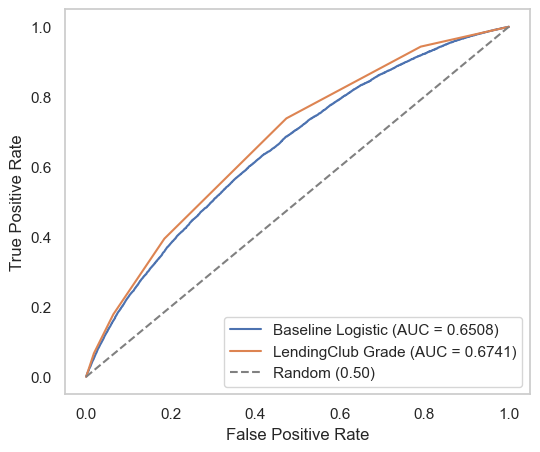

In [62]:
# Comparative Discriminatory Power
grade_numeric = comparison_df['grade'].map(
    {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}
)

baseline_test_probs = final_model.predict_proba(X_test)[:, 1]
baseline_auc = roc_auc_score(y_test, baseline_test_probs)
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, baseline_test_probs)

grade_auc = roc_auc_score(y_test, grade_numeric)
fpr_grade, tpr_grade, _ = roc_curve(y_test, grade_numeric)

grade_gini = 2 * grade_auc - 1            # Gini Coefficent
grade_ks = np.max(tpr_grade - fpr_grade)  # KS Statistic

display(HTML(f"""</br>
    <b>LendingClub Grade Performance</b></br>
    
    Test AUC: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>    
        {grade_auc:.4f}
    </span></br>
    
    Gini Coefficient: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>    
        {grade_gini:.4f}
    </span></br>
    
    Test KS Statistic: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {grade_ks:.4f}
    </span><br>
"""))

plt.figure(figsize = (6, 5))

plt.plot(
    fpr_baseline,
    tpr_baseline,
    label = f'Baseline Logistic (AUC = {baseline_auc:.4f})'
)

plt.plot(
    fpr_grade,
    tpr_grade,
    label = f'LendingClub Grade (AUC = {grade_auc:.4f})'
)

plt.plot([0, 1], [0, 1], linestyle = '--', color = 'gray', label = 'Random (0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(None)
plt.legend()

display(HTML('<br><b>Figure 8: ROC Curve » Baseline Model vs LendingClub Grade (Test Sample)</b>'))
plt.show()


**Figure 8** 

- LendingClub grades outperform the baseline (AUC 0.674 vs 0.651)
- Relatively small gap indicates strong baseline performance despite simpler, transparent modeling
- Gap plausibly reflects LendingClub's access to third-party/non-traditional credit data at origination, not a modeling advantage


### 6.4 Portfolio Risk Band Construction

- Score deciles grouped into five risk segments from Very High Risk (36.39%) to Prime (8.69%)
- Default rates decline progressively across segments
- Produces a 27.70 percentage-point spread in default rates
- Provides stable and interpetable segmentation
- Supports transparent thresholds for underwriting, pricing, and portfolio management


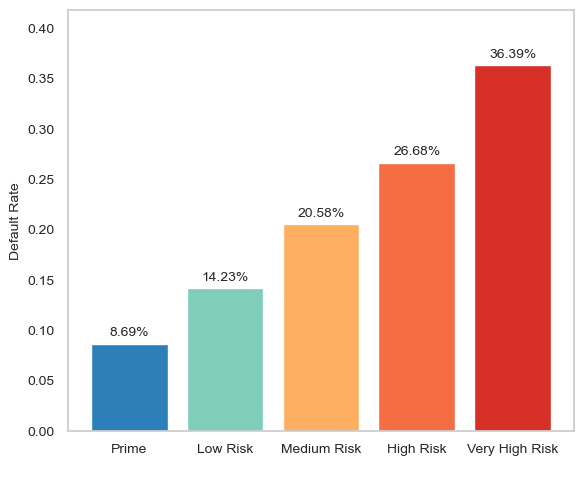

In [63]:
# Model Discrimination & Risk Band Construction
test_auc = roc_auc_score(y_test, test_pd)
gini = 2 * test_auc - 1
fpr, tpr, _ = roc_curve(y_test, test_pd)
ks_stat = (tpr - fpr).max()

display(HTML(f"""<br>
    <b>Baseline Model Performance (Test Sample)</b><br>

    Test AUC:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 6px;'>
    {test_auc:.4f}
    </span><br>

    Gini Coefficient:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 6px;'>
    {gini:.4f}
    </span><br>

    Test KS Statistic:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 6px;'>
    {ks_stat:.4f}
    </span><br><br>
"""))

def assign_band(decile):
    
    if decile <= 1:
        return 'Very High Risk'
    elif decile <= 3:
        return 'High Risk'
    elif decile <= 6:
        return 'Medium Risk'
    elif decile <= 8:
        return 'Low Risk'
    else:
        return 'Prime'

comparison_df['risk_band'] = comparison_df['model_decile'].apply(assign_band)

band_summary = (
    comparison_df
        .groupby('risk_band')['default']
        .agg(['count', 'mean'])
        .rename(columns = {'mean': 'default_rate'})
        .reset_index()
)

band_order = [
    'Prime',
    'Low Risk',
    'Medium Risk',
    'High Risk',
    'Very High Risk'
]

band_summary['risk_band'] = pd.Categorical(
    band_summary['risk_band'],
    categories = band_order,
    ordered = True
)

band_summary = band_summary.sort_values('risk_band')

colors = ['#2c7fb8', '#7fcdbb', '#fdae61', '#f46d43', '#d73027']

plt.figure(figsize = (6, 5))

bars = plt.bar(
    band_summary['risk_band'],
    band_summary['default_rate'],
    color = colors
)

plt.ylabel('Default Rate', fontsize = 10)
plt.xlabel(' ', fontsize = 10)
plt.xticks(rotation = 0, fontsize = 10)
plt.yticks(fontsize = 10)
#plt.grid(axis = 'y', linestyle = '--', alpha = 0.3)
plt.grid(None)

max_rate = band_summary['default_rate'].max()
plt.ylim(0, max_rate * 1.15)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (max_rate * 0.02),
        f'{height:.2%}',
        ha = 'center',
        fontsize = 10,
    )

plt.tight_layout()

display(HTML('<br><b>Figure 9: Default Rate by Model Risk Band (Test Sample)</b>'))
plt.show()


**Figure 9** 

- Risk segments show a smooth, ordered gradient with consistent spacing
- Aggregation preserves underlying ranking structure
- Confirms stability of the segmentation framework


In [64]:
# Memory Management
rows = []
for name, obj in list(globals().items()):
    if not name.startswith('_'):
        try:
            size_mb = sys.getsizeof(obj) / 1e6
            rows.append((name, type(obj).__name__, size_mb))
        except:
            pass

mem_df = pd.DataFrame(rows, columns = ['variable', 'type', 'size_mb'])
mem_df = mem_df.sort_values(by = 'size_mb', ascending = False).reset_index(drop = True)

display(mem_df.head(10))


,variable,type,size_mb
0,accepted_df,DataFrame,6283.376457
1,grouped_status,Series,134.023339
2,accepted_df_final,DataFrame,64.131033
3,X_train_with_target,DataFrame,38.393638
4,train_df,DataFrame,38.393638
5,data,DataFrame,37.675086
6,X_train_int,DataFrame,33.649210
7,X_train,DataFrame,32.930658
8,test_df,DataFrame,25.737427
9,X_test_int,DataFrame,22.556119


In [65]:
del accepted_df, accepted_df_final


## 7.0 Comparative Analysis

- Baseline provides transparency, interpretability, and continuous risk estimates
- Retained as a stable baseline for model comparison
- Subsequent analysis assesses whether enhancements improve performance without sacrificing stability
- Evaluation metrics AUC (model discrimination), KS Statistic (class separation strength), Decile Default Rates (risk ranking effectiveness)
- AUC provides a threshold-independent measure of model discrimination and evaluates ranking performance without distortion from class imbalance
- Generated predicted default probabilities to assess risk ranking
- Baseline benchmark AUC = 0.6509, KS = 0.2153
- Stable reference point for evaluating improvements
- Statistical Significance Testing: DeLong test used to determine if AUC differences reflect true model improvement rather than random variation

**Cross-Validation**
- 7-fold cross-validation used for hyperparameter tuning
- Performance evaluated using average AUC across folds, providing stable and reliable performance estimate
- Monte Carlo CV considered but not used due to high computational cost
- 7-fold CV provided balanced trade-off between efficiency and accuracy

**Hyperparameter Tuning**
- Hyperparameters tuned using grid search
- Candidate values based on standard practice for each model
- Optimal parameters selected via cross-validated performance
- Ensures consistent and comparable model tuning
- Balances computational efficiency and performance


### 7.1 XGBoost: Nonlinear Structural Extension

- XGBoost model with tree-based learning
- Pipeline applied encoding for categorical variables with a reference level omitted
- Tuned key parameters: trees (200–400), depth (3–4), learning rate (0.03–0.1)
- 7-fold cross-validation for hyperparameter tuning model evaluation
- Optimized using ROC AUC due to class imbalance with best model selected with highest average validation AUC


In [66]:
# XGBoost
numeric_features = X_train.select_dtypes(include = ['number']).columns
categorical_features = [
    col for col in X_train.select_dtypes(include = ['object', 'category']).columns
    if col != 'id'
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers = [
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop = 'first', handle_unknown = 'ignore'), categorical_features)
    ]
)

# Base Model
xgb_model = XGBClassifier(
    subsample = 0.8,
    colsample_bytree = 0.8,
    reg_lambda = 1.0,
    reg_alpha = 0.0,
    objective = 'binary:logistic',
    eval_metric = 'auc',
    random_state = 7,
    n_jobs = 8,
    tree_method = 'hist'
)

# Pipeline
xgb_pipeline = Pipeline(steps = [('preprocessor', preprocessor), ('clf', xgb_model)])

# Parameter Grid
param_grid = {
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [3, 4],
    'clf__learning_rate': [0.03, 0.05, 0.1]
}

# Grid Search
grid_xgb = GridSearchCV(
    estimator = xgb_pipeline,
    param_grid = param_grid,
    cv = 7,
    scoring = 'roc_auc',
    n_jobs = 8,
    verbose = 1
)

grid_xgb.fit(X_train, y_train)

# Best Model
best_xgb_model = grid_xgb.best_estimator_

print(f"Best Params: {grid_xgb.best_params_}")
print(f"Best CV AUC: {grid_xgb.best_score_:.4f}")


Fitting 7 folds for each of 12 candidates, totalling 84 fits
Best Params: {'clf__learning_rate': 0.03, 'clf__max_depth': 4, 'clf__n_estimators': 400}
Best CV AUC: 0.6569


#### 7.1.1 Final Model

- Best parameters selected using 7-fold cross-validation: learning rate = 0.03, max depth = 4, number of estimators = 400 (CV AUC = 0.6569)
- Evaluated using ROC AUC with Training AUC = 0.7339 and Test AUC = 0.6521
- Incremental improvement over logistic baseline (Test AUC = 0.6521 vs 0.6509)
- Moderate gap between train and test AUC indicates some evidence of overfitting but acceptable generalization


In [67]:
# Final XGBoost
numeric_features = X_train.select_dtypes(include = ['number']).columns
categorical_features = [
    col for col in X_train.select_dtypes(include = ['object', 'category']).columns
    if col != 'id'
]

xgb_final = XGBClassifier(
    n_estimators = 400,
    max_depth = 4,
    learning_rate = 0.1,
    subsample = 0.8,
    colsample_bytree = 0.8,
    reg_lambda = 1.0,
    reg_alpha = 0.0,
    objective = 'binary:logistic',
    eval_metric = 'auc',
    random_state = 7,
    n_jobs = 8,
    tree_method = 'hist'
)

# Pipeline
xgb_pipeline_final = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('clf', xgb_final)
])

xgb_pipeline_final.fit(X_train, y_train)

# Evaluate
train_auc = roc_auc_score(y_train, xgb_pipeline_final.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, xgb_pipeline_final.predict_proba(X_test)[:, 1])

display(HTML(f"""</br>
    <b>XGBoost (Final Model)</b></br>

    Training AUC: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_auc:.4f}
    </span></br>

    Test AUC: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_auc:.4f}
    </span>
"""))


#### 7.1.2 KS Statistic & Risk Ranking

- Loans ranked into 10 risk deciles based on predicted probabilities
- Default rates increase consistently from lowest to highest risk decile
- Top decile default rate = 40.40% vs overall = 22.38%
- Lowest decile default rate = 7.86%
- Strong separation between high- and low-risk borrowers
- KS Statistic (Test) = 0.2205, improved vs baseline (0.2153)
- Model provides stronger risk segmentation than baseline


In [68]:
# KS Statistic + Decile Default Rates
xgboost_probs = xgb_pipeline_final.predict_proba(X_test)[:, 1]

results_df = pd.DataFrame({
    'y_true': y_test,
    'score': xgboost_probs
})

# KS Statistic
results_df = results_df.sort_values('score', ascending = False)
results_df['cum_good'] = (results_df['y_true'] == 0).cumsum()
results_df['cum_bad'] = (results_df['y_true'] == 1).cumsum()

total_good = (results_df['y_true'] == 0).sum()
total_bad = (results_df['y_true'] == 1).sum()

results_df['cum_good_rate'] = results_df['cum_good'] / total_good
results_df['cum_bad_rate'] = results_df['cum_bad'] / total_bad

results_df['ks'] = np.abs(results_df['cum_bad_rate'] - results_df['cum_good_rate'])
ks_stat = results_df['ks'].max()

# Decile Table
results_df['decile'] = pd.qcut(results_df['score'], 10, labels = False)

decile_table = (
    results_df
    .groupby('decile')
    .agg(
        observations = ('y_true', 'count'),
        default_rate = ('y_true', 'mean')
    )
    .sort_index(ascending = False)
    .reset_index()
)

overall_default = results_df['y_true'].mean()

display(HTML('<br><b>Table 20: Decile Default Rates (XGBoost)</b>'))
display(decile_table)

display(HTML(f"""</br>
    <b>Model Performance Summary</b></br>

    KS Statistic (Test):
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {ks_stat:.4f}
    </span></br>

    Overall Default Rate:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {overall_default:.4f}
    </span></br>
    
    Top Decile Default Rate:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {decile_table.iloc[0]['default_rate']:.4f}
    </span>
"""))


,decile,observations,default_rate
0,9,6018,0.403955
1,8,6018,0.324526
2,7,6018,0.288800
3,6,6018,0.253739
4,5,6018,0.225490
5,4,6018,0.191924
6,3,6017,0.185308
7,2,6019,0.164978
8,1,6018,0.120638
9,0,6019,0.078584


**Table 20** 

- Improvements concentrated in the highest-risk decile
- Lower deciles remain largely unchanged
- Consistent spacing with no ranking irregularities
- Nonlinear modeling enhances separation at the top end, overall discrimination shows some improvement


### 7.2 Random Forest: Nonlinear Structural Extension

- Random Forest model using ensemble tree learning
- Pipeline applied encoding for categorical variables with a reference level omitted
- Tuned key parameters: trees (200–300), depth (6–10), min leaf size (10–20), features per split (√p or 50%)
- 7-fold cross-validation for hyperparameter tuning and model evaluation
- Optimized using ROC AUC due to class imbalance with best model selected with highest average validation AUC


In [69]:
# Random Forest
numeric_features = X_train.select_dtypes(include = ['number']).columns
categorical_features = [
    col for col in X_train.select_dtypes(include = ['object', 'category']).columns if col != 'id'
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers = [
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop = 'first', handle_unknown = 'ignore'), categorical_features)
    ]
)

# Base Model
rf_model = RandomForestClassifier(random_state = 7, n_jobs = 8)

# Pipeline
rf_pipeline = Pipeline(steps = [('preprocessor', preprocessor), ('clf', rf_model)])

# Parameter Grid
param_grid = {
    'clf__n_estimators': [200, 300],
    'clf__max_depth': [6, 8, 10],
    'clf__min_samples_leaf': [10, 20],
    'clf__max_features': ['sqrt', 0.5]
}

# Grid Search
grid_rf = GridSearchCV(
    estimator = rf_pipeline,
    param_grid = param_grid,
    cv = 7,
    scoring = 'roc_auc',
    n_jobs = 8,
    verbose = 1
)

grid_rf.fit(X_train, y_train)

# Best Model
best_rf_model = grid_rf.best_estimator_

print(f"Best Params: {grid_rf.best_params_}")
print(f"Best CV AUC: {grid_rf.best_score_:.4f}")


Fitting 7 folds for each of 24 candidates, totalling 168 fits
Best Params: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 20, 'clf__n_estimators': 300}
Best CV AUC: 0.6524


#### 7.2.1 Final Model

- Best parameters selected using 7-fold cross-validation: max depth = 10, max features = sqrt, minimum samples per leaf = 20, number of estimators = 300 (CV AUC = 0.6524)
- Captures nonlinear relationships through bagging and feature randomness
- Evaluated using ROC AUC with Training AUC = 0.7368 and Test AUC = 0.6522
- Some improvement over logistic baseline (Test AUC = 0.6522 vs 0.6509)
- Larger gap between train and test AUC indicates moderate overfitting relative to other models


In [70]:
# Final Random Forest Model
numeric_features = X_train.select_dtypes(include = ['number']).columns
categorical_features = [
    col for col in X_train.select_dtypes(include = ['object', 'category']).columns if col != 'id'
]

rf_pipeline_final = grid_rf.best_estimator_
rf_pipeline_final.fit(X_train, y_train)

# Evaluate
train_auc = roc_auc_score(y_train, rf_pipeline_final.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, rf_pipeline_final.predict_proba(X_test)[:, 1])

display(HTML(f"""</br>
    <b>Random Forest (Final Model)</b></br>

    Training AUC:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_auc:.4f}
    </span></br>

    Test AUC:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_auc:.4f}
    </span>
"""))


#### 7.2.2 KS Statistic & Risk Ranking

- Loans ranked into 10 risk deciles based on predicted probabilities
- Default rates increase consistently from lowest to highest risk decile
- Top decile default rate = 41.11% vs overall = 22.38%
- Lowest decile default rate = 7.73%
- Strong separation between high- and low-risk borrowers
- KS Statistic (Test) = 0.2164, consistent with baseline (0.2153)
- Model supports risk segmentation, without meaningful improvement


In [71]:
# KS Statistic + Decile Default Rates
rf_probs = rf_pipeline_final.predict_proba(X_test)[:, 1]

results_df = pd.DataFrame({
    'y_true': y_test,
    'score': rf_probs
})

# KS Statistic
results_df = results_df.sort_values('score', ascending = False)

results_df['cum_good'] = (results_df['y_true'] == 0).cumsum()
results_df['cum_bad'] = (results_df['y_true'] == 1).cumsum()

total_good = (results_df['y_true'] == 0).sum()
total_bad = (results_df['y_true'] == 1).sum()

results_df['cum_good_rate'] = results_df['cum_good'] / total_good
results_df['cum_bad_rate'] = results_df['cum_bad'] / total_bad

results_df['ks'] = np.abs(
    results_df['cum_bad_rate'] - results_df['cum_good_rate']
)

ks_stat = results_df['ks'].max()

# Decile Table
results_df['decile'] = pd.qcut(results_df['score'], 10, labels = False)

decile_table = (
    results_df
    .groupby('decile')
    .agg(
        observations = ('y_true', 'count'),
        default_rate = ('y_true', 'mean')
    )
    .sort_index(ascending = False)
    .reset_index()
)

overall_default = results_df['y_true'].mean()

display(HTML('<br><b>Table 21: Decile Default Rates</b>'))
display(decile_table)

display(HTML(f"""</br>
    <b>Model Performance Summary</b></br>

    KS Statistic (Test):
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {ks_stat:.4f}
    </span></br>

    Overall Default Rate:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {overall_default:.4f}
    </span></br>

    Top Decile Default Rate:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {decile_table.iloc[0]['default_rate']:.4f}
    </span>
"""))


,decile,observations,default_rate
0,9,6018,0.411100
1,8,6018,0.320871
2,7,6018,0.283649
3,6,6018,0.246926
4,5,6018,0.230143
5,4,6018,0.198903
6,3,6018,0.185610
7,2,6018,0.157195
8,1,6018,0.126288
9,0,6019,0.077255


/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


**Table 21** 

- Improvements concentrated in the highest-risk decile
- Default rates decrease steadily across lower-risk segments
- Consistent spacing with no ranking irregularities
- Nonlinear modeling enhances separation at the top end, overall discrimination shows almost no improvement


### 7.3 Support Vector Machine (SVM): Nonlinear Structural Extension

- SVM with RBF kernel
- Pipeline applied standardization for numeric features and encoding for categorical variables with a reference level omitted
- Tuned key parameters: SGD regularization (alpha = 0.0001–0.001) and kernel approximation settings (gamma = 0.01–1, n_components = 200–500)
- 7-fold cross-validation for hyperparameter tuning and model evaluation
- Optimized using ROC AUC due to class imbalance with best model selected with highest average validation AUC
- SVM implemented with kernel approximation (e.g., Nystroem) to capture nonlinear relationships efficiently while reducing computational cost and maintaining performance


In [72]:
# Support Vector Machine (Approximated)
numeric_features = X_train.select_dtypes(include = ['number']).columns
categorical_features = [
    col for col in X_train.select_dtypes(include = ['object', 'category']).columns
    if col != 'id'
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), categorical_features)
    ]
)

# Pipeline
svm_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('nystroem', Nystroem(kernel = 'rbf', random_state = 7)),
    ('clf', SGDClassifier(
        loss = 'hinge',
        class_weight = 'balanced',
        max_iter = 1000,
        tol = 1e-3,
        random_state = 7
    ))
])

# Parameter Grid
param_grid_svm = {
    'nystroem__gamma': [0.01, 0.1, 1],
    'nystroem__n_components': [200, 300, 500],
    'clf__alpha': [0.0001, 0.001]
}

# Grid Search
svm_grid = GridSearchCV(
    estimator = svm_pipeline,
    param_grid = param_grid_svm,
    cv = 7,
    scoring = 'roc_auc',
    n_jobs = 4,
    verbose = 1,
    error_score = 'raise'
)

svm_grid.fit(X_train, y_train)

# Best Model
best_svm_model = svm_grid.best_estimator_

print(f"Best Params: {svm_grid.best_params_}")
print(f"Best CV AUC: {svm_grid.best_score_:.4f}")


Fitting 7 folds for each of 18 candidates, totalling 126 fits
Best Params: {'clf__alpha': 0.0001, 'nystroem__gamma': 0.01, 'nystroem__n_components': 500}
Best CV AUC: 0.6542


#### 7.3.1 Final Model

- Best parameters selected using 7-fold cross-validation: alpha = 0.0001, gamma = 0.01, n_components = 500 (CV AUC = 0.6542)
- Captures nonlinear relationships through the RBF kernel
- Evaluated using ROC AUC  with Training AUC = 0.6570 and Test AUC = 0.6537
- Performance improved slightly over baseline (Test AUC = 0.6537 vs 0.6509)
- Minimal gap between train and test AUC indicates stable generalization with no evidence of overfitting


In [73]:
# Final SVM Model (Approximated)
numeric_features = X_train.select_dtypes(include = ['number']).columns
categorical_features = [
    col for col in X_train.select_dtypes(include = ['object', 'category']).columns
    if col != 'id'
]

svm_pipeline_final = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('nystroem', Nystroem(
        kernel = 'rbf',
        gamma = 0.01,
        n_components = 500,
        random_state = 7
    )),
    ('clf', SGDClassifier(
        loss = 'hinge',
        class_weight = 'balanced',
        alpha = 0.0001,
        max_iter = 1000,
        tol = 1e-3,
        random_state = 7
    ))
])

svm_pipeline_final.fit(X_train, y_train)

print('svm_pipeline_final fitted.')


svm_pipeline_final fitted.


In [74]:
# Final SVM: Evaluate AUC
train_scores = svm_pipeline_final.decision_function(X_train)
test_scores = svm_pipeline_final.decision_function(X_test)

train_auc = roc_auc_score(y_train, train_scores)
test_auc = roc_auc_score(y_test, test_scores)

display(HTML(f"""</br>
    <b>Support Vector Machine (Final Model)</b></br>

    Training AUC: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {train_auc:.4f}
    </span></br>

    Test AUC: 
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {test_auc:.4f}
    </span>
"""))


#### 7.3.2 KS Statistic & Risk Ranking

- Loans ranked into 10 risk deciles based on predicted probabilities
- Default rates increase consistently from lowest to highest risk decile
- Top decile default rate = 41.34% vs overall = 22.38%
- Lowest decile default rate = 7.81%
- Strong separation between high- and low-risk borrowers
- KS Statistic (Test) = 0.2207, improvement over baseline (0.2153)
- Model supports risk segmentation, without meaningful improvement


In [75]:
# KS Statistic + Decile Default Rates
test_scores = svm_pipeline_final.decision_function(X_test)

results_df = pd.DataFrame({
    'y_true': y_test,
    'score': test_scores
})

# KS Statistic
results_df = results_df.sort_values('score', ascending = False)

results_df['cum_good'] = (results_df['y_true'] == 0).cumsum()
results_df['cum_bad'] = (results_df['y_true'] == 1).cumsum()

total_good = (results_df['y_true'] == 0).sum()
total_bad = (results_df['y_true'] == 1).sum()

results_df['cum_good_rate'] = results_df['cum_good'] / total_good
results_df['cum_bad_rate'] = results_df['cum_bad'] / total_bad
results_df['ks'] = np.abs(results_df['cum_bad_rate'] - results_df['cum_good_rate'])

ks_stat = results_df['ks'].max()

# Decile Table
results_df['decile'] = pd.qcut(
    results_df['score'],
    10,
    labels = False,
    duplicates = 'drop'
)

decile_table = (
    results_df
    .groupby('decile')
    .agg(
        observations = ('y_true', 'count'),
        default_rate = ('y_true', 'mean')
    )
    .sort_index(ascending = False)
    .reset_index()
)

overall_default = results_df['y_true'].mean()

display(HTML('<br><b>Table 22: Decile Default Rates (SVM)</b>'))
display(decile_table)

display(HTML(f"""</br>
    <b>Model Performance Summary</b></br>

    KS Statistic (Test):
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {ks_stat:.4f}
    </span></br>

    Overall Default Rate:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {overall_default:.4f}
    </span></br>

    Top Decile Default Rate:
    <span style='background-color:#fff3b0; font-weight:bold; padding:2px 4px;'>
        {decile_table.iloc[0]['default_rate']:.4f}
    </span>
"""))


,decile,observations,default_rate
0,9,6018,0.413426
1,8,6018,0.325856
2,7,6018,0.282818
3,6,6018,0.246760
4,5,6018,0.223330
5,4,6018,0.199069
6,3,6018,0.187438
7,2,6018,0.153872
8,1,6018,0.127285
9,0,6019,0.078086


**Table 22**

- Improvements concentrated in the highest-risk decile
- Default rates decrease steadily across lower-risk segments
- Consistent spacing with no ranking irregularities
- Nonlinear modeling enhances separation at the top end, overall discrimination shows some improvement


### 7.4 Results

- Random Forest, XGBoost, and SVM all perform similarly to the baseline, with no model separating itself out visually on the ROC curve
- Logistic regression captures most of the linear risk structure; added nonlinear complexity does not meaningfully change discrimination
- LendingClub grades materially outperform all models


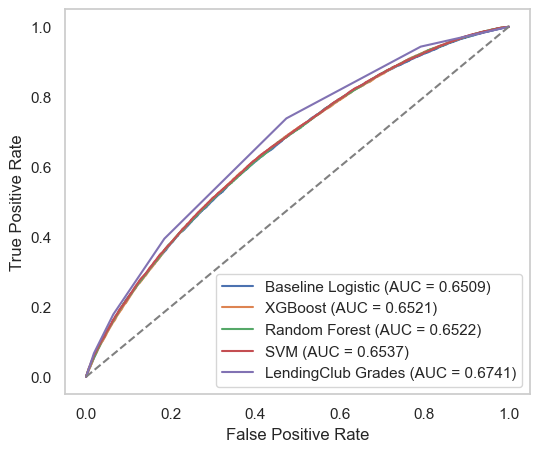

In [76]:
# ROC Curve Comparison - All Models (Test Sample)

# Logistic Baseline Pipeline
baseline_preprocessor = clone(preprocessor)
baseline_preprocessor.transformers[0] = (
    baseline_preprocessor.transformers[0][0],
    baseline_preprocessor.transformers[0][1],
    numeric_features
)

baseline_estimator = clone(logit_pipeline.steps[-1][1])

baseline_model = Pipeline([
    ('preprocessor', baseline_preprocessor),
    ('classifier', baseline_estimator)
])

baseline_model.fit(X_train, y_train)

# Baseline Logistic
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]
baseline_auc = roc_auc_score(y_test, baseline_probs)
fpr_base, tpr_base, _ = roc_curve(y_test, baseline_probs)

# Random Forest
rf_probs = rf_pipeline_final.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

# XGBoost
boosting_probs = xgb_pipeline_final.predict_proba(X_test)[:, 1]
boosting_auc = roc_auc_score(y_test, boosting_probs)
fpr_boost, tpr_boost, _ = roc_curve(y_test, boosting_probs)

# SVM
svm_scores = svm_pipeline_final.decision_function(X_test)
svm_auc = roc_auc_score(y_test, svm_scores)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_scores)

# LendingClub Grades
grade_numeric = comparison_df['grade'].map({'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7})
grade_auc = roc_auc_score(y_test, grade_numeric)
fpr_grade, tpr_grade, _ = roc_curve(y_test, grade_numeric)

# Plot ROC Curves
plt.figure(figsize = (6, 5))

plt.plot(fpr_base, tpr_base, label = f'Baseline Logistic (AUC = {baseline_auc:.4f})')
plt.plot(fpr_boost, tpr_boost, label = f'XGBoost (AUC = {boosting_auc:.4f})')
plt.plot(fpr_rf, tpr_rf, label = f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot(fpr_svm, tpr_svm, label = f'SVM (AUC = {svm_auc:.4f})')
plt.plot(fpr_grade, tpr_grade, label = f'LendingClub Grades (AUC = {grade_auc:.4f})')

plt.plot([0, 1], [0, 1], linestyle = '--', color = 'gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(False)
plt.legend()

display(HTML('<br><b>Figure 10: ROC Curve Comparison Across Models (Test Sample)</b>'))
plt.show()


**Figure 10**

- Baseline, Random Forest, and SVM models show nearly identical ROC curves
- XGBoost provides limited improvement over logistic models
- Increasing model complexity produces limited gains, suggesting most predictive signal is already captured by  linear models


### 7.5 Calibration Assessment

- Rank-ordering metrics (AUC, KS, deciles) measure whether the model separates good and bad loans, not whether its predicted probabilities are numerically accurate
- Calibration checks whether a predicted probability of 20% corresponds to an observed default rate of roughly 20%
- SVM (SGDClassifier, hinge loss) has no native `predict_proba`: its `decision_function` scores are not probabilities, so it is excluded here rather than misrepresented as one
- Ranking order, class separation, discrimination, and calibration are all weighed together in the final model assessment (Section 7.6): ranking metrics determine whether a model can distinguish risk, while calibration determines whether its probability estimates can be trusted for pricing, reserving, or expected-loss calculations


#### 7.5.1 Calibration Curves & Brier Score

- Predicted probabilities binned into deciles; mean predicted probability compared against the observed default rate within each bin
- Points on the 45° diagonal indicate well-calibrated probabilities; points above/below indicate under-/over-prediction
- Brier score summarizes calibration and resolution in a single number (lower is better; 0 = perfect)
- Baseline Logistic is poorly calibrated: predicted probabilities run well above observed default rates across the entire range (e.g., ~70% predicted vs ~41% observed at the high end), consistent with `class_weight='balanced'` improving separation at the cost of distorting the probability scale
- XGBoost and Random Forest track the diagonal closely and post much better Brier scores (0.1664 and 0.1672 vs 0.2309 for the baseline)
- Despite similar AUC/KS to the baseline (Section 7.4), XGBoost and Random Forest produce meaningfully more trustworthy probability estimates: a distinction rank-ordering metrics alone would have missed


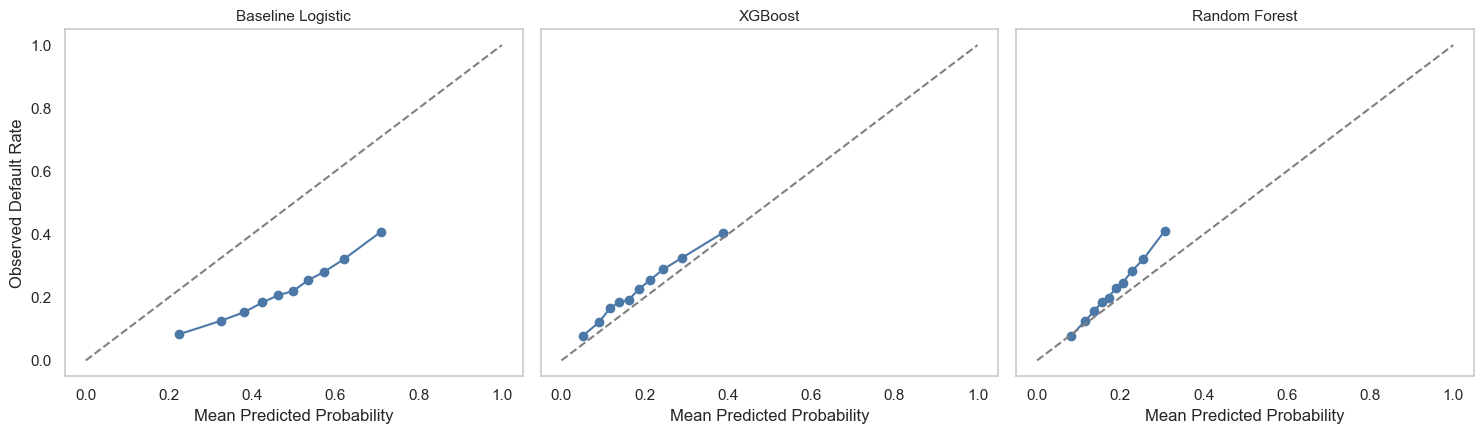

,Model,Brier Score
0,Baseline Logistic,0.2309
1,XGBoost,0.1664
2,Random Forest,0.1672


In [77]:
# Calibration Curves & Brier Score
calibration_models = {
    'Baseline Logistic': baseline_probs,
    'XGBoost': boosting_probs,
    'Random Forest': rf_probs
}

fig, axes = plt.subplots(1, 3, figsize = (15, 4.5), sharey = True)

brier_results = []

for ax, (name, probs) in zip(axes, calibration_models.items()):

    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins = 10, strategy = 'quantile')
    brier = brier_score_loss(y_test, probs)

    brier_results.append({'Model': name, 'Brier Score': round(brier, 4)})

    ax.plot(prob_pred, prob_true, marker = 'o', color = '#4C78A8')
    ax.plot([0, 1], [0, 1], linestyle = '--', color = 'gray')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_title(name, fontsize = 11)
    ax.grid(False)

axes[0].set_ylabel('Observed Default Rate')
plt.tight_layout()

display(HTML('<br><b>Figure 11: Calibration Curves by Model (Test Sample)</b>'))
plt.show()

brier_df = pd.DataFrame(brier_results)

display(HTML('<br><b>Table 23: Brier Score Summary</b>'))
display(brier_df)

display(HTML('''<br>
    <i>SVM excluded: SGDClassifier(loss='hinge') produces decision_function scores,
    not probabilities, so calibration and Brier score are not meaningful for it without
    an additional calibration step (e.g. Platt scaling via CalibratedClassifierCV).</i>
'''))


#### 7.5.2 Calibration Comparison

- Overlaying all applicable models on one plot highlights their relative calibration quality
- Baseline Logistic sits furthest from the diagonal at every bin; XGBoost and Random Forest are nearly indistinguishable from each other and stay close to the diagonal throughout


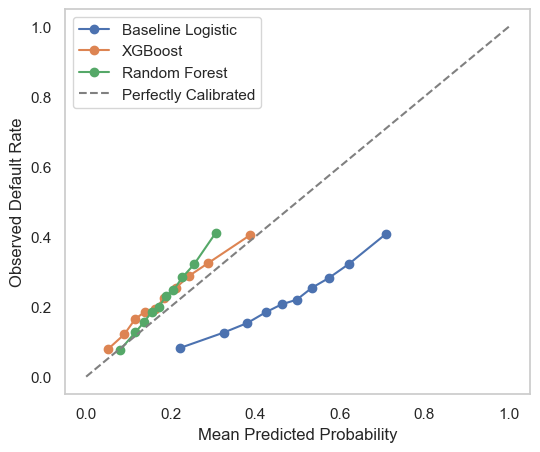

In [78]:
# Calibration Comparison Plot
plt.figure(figsize = (6, 5))

for name, probs in calibration_models.items():
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins = 10, strategy = 'quantile')
    plt.plot(prob_pred, prob_true, marker = 'o', label = name)

plt.plot([0, 1], [0, 1], linestyle = '--', color = 'gray', label = 'Perfectly Calibrated')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Default Rate')
plt.grid(False)
plt.legend()

display(HTML('<br><b>Figure 12: Calibration Comparison Across Models (Test Sample)</b>'))
plt.show()


#### 7.5.3 Post-Hoc Recalibration (Platt Scaling)

- Tests whether the baseline's miscalibration is actually caused by `class_weight='balanced'`, rather than just asserting it, by applying a post-hoc sigmoid (Platt) recalibration on top of the existing model
- `CalibratedClassifierCV(method='sigmoid', cv=5)` learns a monotonic remapping of a model's scores onto calibrated probabilities; monotonic transforms cannot change rank order, so AUC/KS are expected to be unchanged before vs after
- Confirmed: Baseline Logistic AUC is unchanged (0.6509 to 0.6509), while Brier Score drops from 0.2309 to 0.1667, on par with XGBoost (0.1664) and Random Forest (0.1672)
- The baseline's miscalibration was entirely an artifact of `class_weight='balanced'`, not a genuine limitation of the linear model or a real tradeoff against the more complex models


In [79]:
# Post-Hoc Recalibration: Baseline Logistic
baseline_calibrated = CalibratedClassifierCV(estimator = clone(logit_pipeline), method = 'sigmoid', cv = 5)
baseline_calibrated.fit(X_train, y_train)
baseline_probs_calibrated = baseline_calibrated.predict_proba(X_test)[:, 1]

print('Recalibrated baseline fitted.')


Recalibrated baseline fitted.


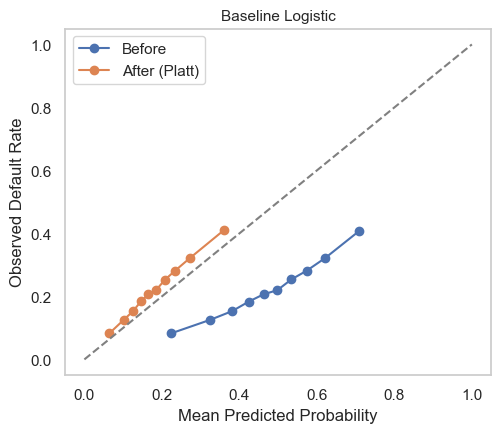

In [80]:
# Calibration Curve: Before vs After Recalibration
plt.figure(figsize = (5.5, 4.5))

prob_true_before, prob_pred_before = calibration_curve(y_test, baseline_probs, n_bins = 10, strategy = 'quantile')
prob_true_after, prob_pred_after = calibration_curve(y_test, baseline_probs_calibrated, n_bins = 10, strategy = 'quantile')

plt.plot(prob_pred_before, prob_true_before, marker = 'o', label = 'Before')
plt.plot(prob_pred_after, prob_true_after, marker = 'o', label = 'After (Platt)')
plt.plot([0, 1], [0, 1], linestyle = '--', color = 'gray')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Default Rate')
plt.title('Baseline Logistic', fontsize = 11)
plt.legend()
plt.grid(False)

display(HTML('<br><b>Figure 13: Baseline Logistic Calibration, Before vs After Platt Scaling</b>'))
plt.show()


### 7.6 Strategic Model Selection & Governance Considerations

- On ranking order, class separation, and discrimination (AUC, KS, deciles), none of the three alternative models offer a statistically defensible improvement over the baseline
- On calibration, the baseline initially looks worse (Brier 0.2309 vs 0.1664/0.1672 for XGBoost/Random Forest), but Section 7.5.3 shows this is entirely an artifact of `class_weight='balanced'`, not a limitation of the linear model itself
- A simple post-hoc Platt scaling step closes the gap completely (Brier 0.2309 to 0.1667) without moving AUC at all, putting the recalibrated baseline on par with XGBoost and Random Forest on both criteria
- There is therefore no statistically or practically defensible case for the added complexity, cost, and reduced interpretability of Random Forest, XGBoost, or SVM over a recalibrated logistic baseline at this sample size
- Logistic regression, recalibrated, is the defensible choice across both ranking-based and probability-dependent decisions
- LendingClub's own grade remains the one model that meaningfully outperforms the baseline; this is more plausibly explained by their access to third-party/non-traditional credit data at origination than by superior modeling technique, reinforcing that feature access, not model complexity, is the more promising lever here


In [81]:
# Logistic Baseline
logit_pipeline.fit(X_train, y_train)
baseline_model = logit_pipeline
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]

# XGBoost
xgb_model = xgb_pipeline_final
boosting_probs = xgb_model.predict_proba(X_test)[:, 1]

# Random Forest
rf_model = rf_pipeline_final
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# SVM
svm_model = svm_pipeline_final
svm_scores = svm_model.decision_function(X_test)

# LendingClub Grade
grade_numeric = comparison_df['grade'].map(
    {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}
)

# Model Comparison
model_dict = {
    'Logistic Baseline': baseline_probs,
    'XGBoost': boosting_probs,
    'Random Forest': rf_probs,
    'SVM': svm_scores,
    'LendingClub Grades': grade_numeric
}

# Models with genuine probability outputs. Brier score is only meaningful for these -
# SVM's decision_function scores and LendingClub's ordinal grade codes are not probabilities.
probability_models = {'Logistic Baseline', 'XGBoost', 'Random Forest'}

# Recalibrated (post-hoc Platt scaling) probabilities, from Section 7.5.3 - baseline only
recalibrated_probs = {'Logistic Baseline': baseline_probs_calibrated}

# Evaluation Metrics
y_array = np.asarray(y_test)

results = []
for name, scores in model_dict.items():

    score_array = np.asarray(scores)

    auc = roc_auc_score(y_array, score_array)
    ks = compute_ks(y_array, score_array)
    gini = 2 * auc - 1
    brier = brier_score_loss(y_array, score_array) if name in probability_models else None
    brier_after = brier_score_loss(y_array, np.asarray(recalibrated_probs[name])) if name in recalibrated_probs else None

    results.append({
        'Model': name,
        'Test AUC': round(auc, 4),
        'KS Statistic': round(ks, 4),
        'Gini Coefficient': round(gini, 4),
        'Brier Score': round(brier, 4) if brier is not None else 'N/A',
        'Brier Score (After)': round(brier_after, 4) if brier_after is not None else 'N/A'
    })

# Final Comparison
comparison_table = pd.DataFrame(results)

display(HTML('<br><b>Table 24: Comparative Model Performance Table</b>'))
display(comparison_table)


,Model,Test AUC,KS Statistic,Gini Coefficient,Brier Score,Brier Score (After)
0,Logistic Baseline,0.6509,0.2152,0.3018,0.2309,0.1667
1,XGBoost,0.6521,0.2205,0.3042,0.1664,N/A
2,Random Forest,0.6522,0.2164,0.3044,0.1672,N/A
3,SVM,0.6537,0.2207,0.3073,N/A,N/A
4,LendingClub Grades,0.6741,0.2646,0.3481,N/A,N/A


**Table 24** 

- Performance differences across models are incremental (AUC, KS, Gini) and, per Section 7.6.1, not statistically distinguishable from the baseline
- SVM posts the highest Test AUC of the three alternatives (0.6537), narrowly ahead of Random Forest (0.6522) and XGBoost (0.6521); differences this small are not a basis for model choice
- Brier Score initially favors XGBoost and Random Forest (0.1664/0.1672 vs 0.2309); the Brier Score (After) column shows the baseline's gap closes entirely with post-hoc recalibration (0.1667, see Section 7.5.3) without any change to AUC
- Logistic baseline, once recalibrated, captures most observable risk and produces trustworthy probabilities within a stable, linear framework


#### 7.6.1 Statistical Significance Testing

- DeLong used for statistical significance testig to compare differences in AUC
- None of Random Forest, XGBoost, or SVM are statistically significant improvements over baseline (p = 0.64, 0.66, 0.46 respectively)
- LendingClub Grades is the only statistically significant comparison (p < 0.001), and demonstrates superior discriminatory power


In [82]:
# Statistical Significance Testing
y_array = np.asarray(y_test)
base_array = np.asarray(baseline_probs)
boosting_array = np.asarray(boosting_probs)
rf_array = np.asarray(rf_probs)
svm_array = np.asarray(svm_scores)
grade_array = np.asarray(grade_numeric)

# Remove NaN
valid_idx = (
    ~np.isnan(base_array) &
    ~np.isnan(boosting_array) &
    ~np.isnan(rf_array) &
    ~np.isnan(svm_array) &
    ~np.isnan(grade_array)
)

y_array = y_array[valid_idx]
base_array = base_array[valid_idx]
boosting_array = boosting_array[valid_idx]
rf_array = rf_array[valid_idx]
svm_array = svm_array[valid_idx]
grade_array = grade_array[valid_idx]

comparisons = [
    ('Baseline vs XGBoost', base_array, boosting_array),
    ('Baseline vs Random Forest', base_array, rf_array),
    ('Baseline vs SVM', base_array, svm_array),
    ('Baseline vs LendingClub Grades', base_array, grade_array)
]

# Run DeLong Tests
results = []
for name, base_scores, model_scores in comparisons:

    auc_base, auc_model, z, p = delong_roc_test(
        y_array,
        base_scores,
        model_scores
    )

    delta_auc = auc_model - auc_base

    results.append({
        'Comparison': name,
        'AUC (Baseline)': round(auc_base, 4),
        'AUC (Model)': round(auc_model, 4),
        'Δ AUC': round(delta_auc, 4),
        'p-value': round(p, 5)
    })

sig_table = pd.DataFrame(results)

display(HTML('<br><b>Table 25: Statistical Significance Testing</b>'))
display(sig_table)


,Comparison,AUC (Baseline),AUC (Model),Δ AUC,p-value
0,Baseline vs XGBoost,0.6509,0.6521,0.0012,0.66486
1,Baseline vs Random Forest,0.6509,0.6522,0.0013,0.63561
2,Baseline vs SVM,0.6509,0.6537,0.0028,0.31578
3,Baseline vs LendingClub Grades,0.6509,0.6741,0.0231,0.00000


## 8.0 Study Limitations & Modeling Assumptions

- Analysis limited to originated loans only
- Uses borrower characteristics available at application
- Excludes proprietary variables
- These constraints limit applicability to similar origination populations and data environments

**Sample Selection Bias**
- Results reflect selection bias from using only originated loans
- Outcomes are observed only for approved applicants
- Estimates capture conditional risk within approved borrowers, not the full applicant population
- Correction would require rejected applicant data, which is unavailable

**Debt-to-Income (DTI) Ratio Measurement**
- DTI is measured at application and reflects repayment capacity at origination
- It can change after funding, especially with debt consolidation
- Should be interpreted as a measure of credit risk assessment, not a post-origination risk signal


## 9.0 Lessons Learned

**Most Important Lesson**
- Performance improvements from increased model complexity were limited, feature quality had much greater impact
- Disney Studios executive, “a good story can make up for bad CGI, but good CGI can never make up for a bad story”
- Similarly, strong features and good data quality can compensate for simpler models, but increased model complexity can't make up for weak features and poor data quality

**Other Impactful Lessons**
- Not all relationships are strictly linear or nonlinear: linear model captured most of the signal, complex nonlinear models provided incremental improvements
- Hyperparameter tuning and evaluation must balance performance with real-world constraints: computational cost, scalability, runtime
- Monte Carlo cross-validation can be powerful but sometimes impractical with large datasets and complex models


## 10.0 Conclusions

**Key Findings**
- Increasing model complexity produced only incremental improvements over baseline logistic regression
- Random Forest and SVM performed similarly to the baseline model
- None of Random Forest, XGBoost, or SVM showed a statistically significant AUC increase over the baseline
- LendingClub grade system outperformed all models in discriminatory power
- The grade advantage is more plausibly explained by data access (third-party/non-traditional credit data used in proprietary underwriting) than by modeling sophistication, reinforcing the feature-quality-over-complexity theme
- On calibration, XGBoost and Random Forest initially appear more trustworthy than the baseline (Brier 0.1664/0.1672 vs 0.2309), but this gap is fully closed by a simple post-hoc recalibration step (Brier 0.1667), confirming it was a modeling-choice artifact (balanced class weighting), not a genuine limitation of the linear model

**Model Performance Insights**
- Evidence of diminishing returns from more complex models
- Limited improvement in KS statistic and ranking performance
- Reinforces that added model complexity needs a statistically demonstrated benefit, not just a numerically higher point estimate, to justify its cost
- More complexity did not meaningfully improve risk separation
- Post-hoc recalibration (Platt scaling) is a cheap, effective fix for calibration issues and does not require abandoning an interpretable model

**Implications for Credit Risk Modeling & Future Work**
- Feature quality more impactful than model complexity
- Logistic regression remains competitive, offering interpretability, stability, ease of implementation
- Complex models may add cost without proportional benefit
- Recalibration should be a standard step before comparing models on calibration; an apparent calibration advantage for a complex model may simply reflect a fixable modeling choice in the baseline, not a genuine limitation of simpler models
- With recalibration applied, the interpretable baseline is competitive on both ranking and probability accuracy, removing the need to trade interpretability for calibration
- Explore alternative feature representations and nonlinear transformations
- Incorporate external data sources: LendingClub's own grade outperforming every model here is consistent with their reported reliance on third-party and non-traditional credit data unavailable in this dataset, suggesting feature access, not model sophistication, is the more promising lever for closing the gap
- Improve performance while maintaining interpretability and stability
- Incorporate macroeconomic context to evaluate how default risk varies across economic cycles (i.e., expansion, stability, contraction)